## Section 0: Overview and Usage

This notebook implements three gate-by-gate simulations for the same validated JSON gate list:

- **Case A**: instantaneous ideal gates.
- **Case B**: pulse-level QuTiP dynamics with no dissipation.
- **Case C**: pulse-level dynamics using support-aware optimized SQR pulses (all loaded SQR gates optimized).

The diagnostic overlays compare **simulated pulse-level** outputs against **Case A ideal references** using stable conventions:

- Fock-resolved Bloch diagnostics use grouped bars by gate index.
- Same color = same Fock manifold `n`; simulated vs ideal are distinguished by filled vs hollow bar style.
- Relative phase uses masked segment-wise unwrapping and ratio-based phase error.
- Pulse-level trajectory overlays keep `X/Y/Z = blue/orange/green`, with simulated solid and ideal dashed.

Usage:

1. Edit the configuration in **Section 2**.
2. Run the notebook top-to-bottom.
3. Inspect overlay diagnostics for Case B and Case C in **Section Y**.
4. Review the weakness comparisons in **Section 8**.
5. Saved figures are written under `outputs/figures/`.

Note: the notebook intentionally omits the old test-suite and final-summary sections.



## Section 1: Imports and Environment Checks


In [1]:
from __future__ import annotations

import importlib
import importlib.metadata
from dataclasses import replace
from pathlib import Path

REQUIRED_HINTS = {
    "numpy": "pip install numpy",
    "matplotlib": "pip install matplotlib",
    "scipy": "pip install scipy",
    "qutip": "pip install qutip",
    "cqed_sim": "pip install -e .",
}

missing = []
versions = {}
for module_name, hint in REQUIRED_HINTS.items():
    try:
        module = importlib.import_module(module_name)
        versions[module_name] = getattr(module, "__version__", "unknown")
    except ModuleNotFoundError as exc:
        missing.append((module_name, hint, exc))

if missing:
    lines = ["Missing required notebook dependencies:"]
    for module_name, hint, exc in missing:
        lines.append(f"  - {module_name}: {exc}. Minimal install hint: {hint}")
    raise ModuleNotFoundError("\n".join(lines))

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
import scipy
from IPython.display import Markdown, display

from cqed_sim.io.gates import load_gate_sequence, render_gate_table
from cqed_sim.observables.fock import conditional_phase_diagnostics, fock_resolved_bloch_diagnostics, relative_phase_debug_values, relative_phase_family_diagnostics
from cqed_sim.observables.weakness import attach_weakness_metrics, comparison_metrics
from cqed_sim.plotting.bloch_plots import plot_bloch_track
from cqed_sim.plotting.gate_diagnostics import (
    plot_fock_resolved_bloch_grouped_bars,
    plot_gate_bloch_trajectory_error,
    plot_gate_bloch_trajectory_overlay,
    plot_phase_error_track,
    plot_phase_overlay_lines,
    save_figure,
)
from cqed_sim.plotting.weakness_plots import (
    plot_cavity_population_comparison,
    plot_component_comparison,
    plot_weakness,
    print_mapping_rows,
)
from cqed_sim.plotting.wigner_grids import plot_wigner_grid
from cqed_sim.simulators.common import build_model
from cqed_sim.simulators.ideal import run_case_a
from cqed_sim.simulators.pulse_unitary import build_gate_segment, run_case_b
from cqed_sim.simulators.trajectories import ideal_gate_bloch_trajectory, simulate_gate_bloch_trajectory

from cqed_sim.calibration.sqr import SQRCalibrationResult
from cqed_sim.io.gates import SQRGate
from cqed_sim.simulators.common import build_frame
from cqed_sim.simulators.pulse_unitary import run_pulse_case

import examples.sqr_multitone_study as sms

def package_version(dist_name: str, default: str = "editable/local") -> str:
    try:
        return importlib.metadata.version(dist_name)
    except importlib.metadata.PackageNotFoundError:
        return default

def _canonical_gate_type(gate_type: str) -> str:
    kind = str(gate_type).strip().upper()
    if "DISP" in kind or kind.startswith("D"):
        return "Displacement"
    if "ROT" in kind or kind.startswith("R"):
        return "Rotation"
    if "SQR" in kind or kind.startswith("S"):
        return "SQR"
    return str(gate_type)

def _segment_time_grid(duration_s: float, dt_s: float) -> np.ndarray:
    n_steps = max(2, int(np.ceil(float(duration_s) / float(dt_s))) + 1)
    return np.linspace(0.0, float(duration_s), n_steps, dtype=float)

def _build_pulse_segments(gates, config, track=None):
    model = build_model(config) if track is None else track["metadata"].get("model", build_model(config))
    sqr_map = None if track is None else track["metadata"].get("sqr_calibration_map")
    segments = []
    cursor_s = 0.0
    for gate_index, gate in enumerate(gates, start=1):
        pulses, _, meta = build_gate_segment(gate, model, config, sqr_calibration_map=sqr_map)
        duration_s = max((pulse.t1 for pulse in pulses), default=0.0)
        segments.append(
            {
                "index": int(gate_index),
                "type": _canonical_gate_type(getattr(gate, "type", "")),
                "name": str(getattr(gate, "name", f"gate_{gate_index}")),
                "start_s": float(cursor_s),
                "end_s": float(cursor_s + duration_s),
                "duration_s": float(duration_s),
                "pulses": list(pulses),
                "meta": dict(meta),
            }
        )
        cursor_s += duration_s
    return segments

def _sample_segment_waveform(segment, dt_s: float):
    t_local = _segment_time_grid(float(segment["duration_s"]), float(dt_s))
    waveform = np.zeros_like(t_local, dtype=np.complex128)
    for pulse in segment["pulses"]:
        waveform += pulse.sample(t_local)
    return t_local, waveform

def plot_full_pulse_sequence_by_gate_type(track, gates, config, dt_s: float | None = None):
    dt_used = float(config["dt_s"] if dt_s is None else dt_s)
    segments = _build_pulse_segments(gates, config, track=track)
    colors = {"Rotation": "tab:orange", "Displacement": "tab:blue", "SQR": "tab:green"}

    fig, ax = plt.subplots(figsize=(12.0, 4.2))
    labeled = set()
    for segment in segments:
        t_local, waveform = _sample_segment_waveform(segment, dt_used)
        t_global_ns = (float(segment["start_s"]) + t_local) * 1.0e9
        amp = np.abs(waveform)
        gate_type = segment["type"]
        color = colors.get(gate_type, "0.35")
        label = gate_type if gate_type not in labeled else None
        ax.plot(t_global_ns, amp, color=color, linewidth=1.4, label=label)
        labeled.add(gate_type)

    for segment in segments:
        x_ns = float(segment["start_s"]) * 1.0e9
        ax.axvline(x_ns, color="0.85", linewidth=0.7, alpha=0.8)

    ax.set_title(f"{track['case']}: full pulse sequence (|drive(t)|) by gate type")
    ax.set_xlabel("Time (ns)")
    ax.set_ylabel("|drive(t)| (rad/s)")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right")
    fig.tight_layout()
    return fig

def plot_gate_pulse_time_and_frequency(
    track,
    gates,
    config,
    gate_index: int,
    dt_s: float | None = None,
    freq_min_mhz: float | None = None,
    freq_max_mhz: float | None = None,
    fft_resample_points: int = 4096,
    fft_zero_pad_factor: int = 16,
    remove_dc: bool = False,
    fft_window: str | None = None,
):
    if gate_index < 1 or gate_index > len(gates):
        raise IndexError(f"gate_index must be in [1, {len(gates)}], got {gate_index}.")

    dt_used = float(config["dt_s"] if dt_s is None else dt_s)
    segments = _build_pulse_segments(gates, config, track=track)
    segment = segments[gate_index - 1]
    t_local, waveform = _sample_segment_waveform(segment, dt_used)

    n = int(t_local.size)
    if n < 2:
        raise ValueError("Need at least two samples to compute frequency-domain pulse view.")

    # Use dense resampling for FFT visualization so narrow gates (e.g. rotations)
    # don't look artificially distorted by coarse simulation dt.
    n_fft_time = max(256, int(fft_resample_points))
    t_fft = np.linspace(0.0, float(segment["duration_s"]), n_fft_time, dtype=float)
    waveform_fft = np.zeros_like(t_fft, dtype=np.complex128)
    for pulse in segment["pulses"]:
        waveform_fft += pulse.sample(t_fft)

    fft_input = waveform_fft.copy()
    if remove_dc:
        fft_input = fft_input - np.mean(fft_input)
    if fft_window is not None and str(fft_window).lower() == "hann":
        fft_input = fft_input * np.hanning(fft_input.size)

    zero_pad_factor = max(1, int(fft_zero_pad_factor))
    n_fft_target = max(256, fft_input.size * zero_pad_factor)
    n_fft = int(2 ** np.ceil(np.log2(n_fft_target)))
    dt_fft = float(t_fft[1] - t_fft[0])
    spectrum = np.fft.fftshift(np.fft.fft(fft_input, n=n_fft))
    freqs_hz = np.fft.fftshift(np.fft.fftfreq(n_fft, d=dt_fft))
    spec_mag = np.abs(spectrum)

    freqs_mhz = freqs_hz * 1.0e-6
    if freq_min_mhz is not None and freq_max_mhz is not None:
        f_lo = float(min(freq_min_mhz, freq_max_mhz))
        f_hi = float(max(freq_min_mhz, freq_max_mhz))
        mask = (freqs_mhz >= f_lo) & (freqs_mhz <= f_hi)
        if np.any(mask):
            freqs_plot = freqs_mhz[mask]
            spec_plot = spec_mag[mask]
        else:
            freqs_plot = freqs_mhz
            spec_plot = spec_mag
    else:
        f_lo = None
        f_hi = None
        freqs_plot = freqs_mhz
        spec_plot = spec_mag

    fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.2))
    axes[0].plot(t_local * 1.0e9, waveform.real, color="tab:blue", linewidth=1.2, label="Re")
    axes[0].plot(t_local * 1.0e9, waveform.imag, color="tab:orange", linewidth=1.2, label="Im")
    axes[0].plot(t_local * 1.0e9, np.abs(waveform), color="tab:green", linewidth=1.4, label="|drive|")
    axes[0].set_xlabel("Time within gate (ns)")
    axes[0].set_ylabel("Drive amplitude (rad/s)")
    axes[0].set_title(f"Gate {gate_index}: {segment['type']} ({segment['name']}) time domain")
    axes[0].grid(alpha=0.25)
    axes[0].legend(loc="best")

    axes[1].plot(freqs_plot, spec_plot, color="tab:purple", linewidth=1.2)
    axes[1].set_xlabel("Frequency (MHz)")
    axes[1].set_ylabel("|FFT| (a.u.)")
    if f_lo is None:
        axes[1].set_title(f"Gate {gate_index}: {segment['type']} ({segment['name']}) frequency domain")
    else:
        axes[1].set_title(
            f"Gate {gate_index}: {segment['type']} ({segment['name']}) frequency domain [{f_lo:.1f}, {f_hi:.1f}] MHz"
        )
    axes[1].grid(alpha=0.25)

    fig.tight_layout()
    return fig

def plot_complex_coeff_vector_grid(track, *, title: str, max_n: int, threshold: float, stride: int = 1, max_cols: int = 5):
    if stride < 1:
        raise ValueError("stride must be >= 1")
    snapshots = track["snapshots"]
    if isinstance(snapshots, dict):
        indices = sorted(int(key) for key in snapshots.keys())

        def _get_snapshot(idx: int):
            return snapshots[idx] if idx in snapshots else snapshots[str(idx)]
    else:
        indices = list(range(len(snapshots)))

        def _get_snapshot(idx: int):
            return snapshots[idx]

    selected_indices = [idx for idx in indices if idx % stride == 0]
    if indices and indices[-1] not in selected_indices:
        selected_indices.append(indices[-1])
    if not selected_indices:
        raise ValueError("No gate indices available for plotting.")

    def _stage_label(gate_index: int) -> str:
        if gate_index == 0:
            gate_tag = "I"
        else:
            gate_type = ""
            if "GATES" in globals() and (gate_index - 1) < len(GATES):
                gate = GATES[gate_index - 1]
                gate_type = str(getattr(gate, "type", "")).upper()
            if not gate_type and isinstance(track, dict):
                labels = track.get("gate_labels")
                if isinstance(labels, (list, tuple)) and gate_index < len(labels):
                    gate_type = str(labels[gate_index]).upper()
            if "ROT" in gate_type or gate_type.startswith("R"):
                gate_tag = "R"
            elif "DISP" in gate_type or gate_type.startswith("D"):
                gate_tag = "D"
            elif "SQR" in gate_type or gate_type.startswith("S"):
                gate_tag = "S"
            else:
                gate_tag = gate_type[:1] if gate_type else "?"
        return f"{gate_tag}{gate_index}"

    first_debug = relative_phase_debug_values(
        _get_snapshot(selected_indices[0])["state"],
        max_n=max_n,
        probability_threshold=threshold,
        coherence_threshold=threshold,
    )
    rows0 = first_debug.get("levels", [])
    state_specs = []
    for row in rows0:
        n_level = int(row["n"])
        state_specs.append((f"|g,{n_level}>", n_level, "c_gn_gauge"))
        state_specs.append((f"|e,{n_level}>", n_level, "c_en_gauge"))

    trajectories = {state_label: [] for state_label, _, _ in state_specs}
    global_max_radius = 0.25

    for gate_index in selected_indices:
        debug = relative_phase_debug_values(
            _get_snapshot(gate_index)["state"],
            max_n=max_n,
            probability_threshold=threshold,
            coherence_threshold=threshold,
        )
        rows = {int(row["n"]): row for row in debug.get("levels", [])}
        for state_label, n_level, key in state_specs:
            coeff = complex(np.nan, np.nan)
            row = rows.get(n_level)
            if row is not None and row.get(key) is not None:
                candidate = complex(row[key])
                if np.isfinite(candidate.real) and np.isfinite(candidate.imag):
                    coeff = candidate
                    global_max_radius = max(global_max_radius, float(np.abs(candidate)))
            trajectories[state_label].append(coeff)

    n_panels = len(state_specs)
    n_cols = 1 if n_panels <= 1 else 2
    n_rows = int(np.ceil(n_panels / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 4.0 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    lim = 1.1 * global_max_radius
    stage_colors = plt.cm.viridis(np.linspace(0.0, 1.0, len(selected_indices)))

    for ax_idx, (state_label, _, _) in enumerate(state_specs):
        ax = axes[ax_idx]
        coeffs = trajectories[state_label]
        path_re = []
        path_im = []
        for k, (gate_index, coeff) in enumerate(zip(selected_indices, coeffs)):
            if not (np.isfinite(coeff.real) and np.isfinite(coeff.imag)):
                continue
            color = stage_colors[k]
            ax.plot([0.0, coeff.real], [0.0, coeff.imag], color=color, linewidth=1.1, alpha=0.35)
            ax.scatter(coeff.real, coeff.imag, color=color, s=20)
            ax.text(coeff.real, coeff.imag, _stage_label(gate_index), fontsize=7, color=color, ha="left", va="bottom")
            path_re.append(coeff.real)
            path_im.append(coeff.imag)

        if len(path_re) >= 2:
            ax.plot(path_re, path_im, color="0.2", linewidth=1.1, alpha=0.5)

        ax.axhline(0.0, color="0.6", linewidth=0.8)
        ax.axvline(0.0, color="0.6", linewidth=0.8)
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect("equal", adjustable="box")
        ax.set_title(state_label, fontsize=10)
        ax.grid(alpha=0.2)
        ax.set_xlabel("Re")
        ax.set_ylabel("Im")

    for ax in axes[n_panels:]:
        ax.axis("off")

    fig.suptitle(title)
    fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.96))
    return fig


def _pad_levels(values, n_levels: int) -> np.ndarray:
    arr = np.asarray(values, dtype=float).ravel()
    if arr.size > int(n_levels):
        arr = arr[: int(n_levels)]
    if arr.size < int(n_levels):
        arr = np.pad(arr, (0, int(n_levels) - arr.size))
    return arr


def _make_case_c_profile(gate: SQRGate, n_levels: int) -> sms.TargetProfile:
    theta = _pad_levels(gate.theta, n_levels)
    phi = _pad_levels(gate.phi, n_levels)
    return sms.TargetProfile(
        name=f"{gate.name}_case_c",
        mode="sequence_sqr_gate",
        theta=np.asarray(theta, dtype=float),
        phi=np.asarray(phi, dtype=float),
        seed=0,
    )


def _case_c_support_params(config, n_levels: int) -> sms.ActiveSupportParams:
    mode = str(config.get("case_c_support_mode", "explicit")).strip().lower()
    if mode == "explicit":
        levels = tuple(int(n) for n in config.get("case_c_support_levels", (0, 1)))
    elif mode == "contiguous":
        max_level = int(config.get("case_c_support_max_level", 1))
        levels = tuple(int(n) for n in range(max(0, max_level) + 1))
    else:
        levels = tuple(int(n) for n in config.get("case_c_support_levels", (0, 1)))
        mode = "explicit"
    levels = tuple(sorted(set(n for n in levels if 0 <= n < int(n_levels))))
    if not levels:
        levels = (0,)
    weights = tuple(float(w) for w in config.get("case_c_support_weights", ()))
    return sms.ActiveSupportParams(
        mode=mode,
        max_level_active=int(config.get("case_c_support_max_level", max(levels))),
        active_levels=levels,
        active_weights=weights,
        infer_weights_from_state=bool(config.get("case_c_support_infer_weights_from_state", True)),
        include_projected_coherent=bool(config.get("case_c_support_include_projected_coherent", True)),
        include_qubit_superposition=bool(config.get("case_c_support_include_qubit_superposition", True)),
        coherent_alpha=complex(
            float(config.get("case_c_support_coherent_alpha_re", 0.9)),
            float(config.get("case_c_support_coherent_alpha_im", 0.2)),
        ),
    )


def _case_c_pulse_params(config) -> sms.PulseParams:
    dt_s = float(config["dt_s"])
    return sms.PulseParams(
        duration_nominal_s=float(config["duration_sqr_s"]),
        sigma_fraction=float(config["sqr_sigma_fraction"]),
        envelope_kind=str(config.get("case_c_envelope_kind", "gaussian")),
        flat_top_rise_fraction=float(config.get("case_c_flat_top_rise_fraction", 0.12)),
        theta_cutoff=float(config.get("sqr_theta_cutoff", 1.0e-10)),
        include_zero_theta_tones=bool(config.get("case_c_include_zero_theta_tones", True)),
        dt_eval_s=dt_s,
        dt_opt_s=float(config.get("case_c_dt_opt_s", max(dt_s, 3.0e-9))),
        max_step_eval_s=float(config.get("case_c_max_step_eval_s", config.get("max_step_s", dt_s))),
        max_step_opt_s=float(config.get("case_c_max_step_opt_s", max(config.get("max_step_s", dt_s), 3.0e-9))),
        qutip_nsteps=int(config.get("case_c_qutip_nsteps", 120000)),
    )


def _case_c_opt_params(config) -> sms.OptimizationParams:
    mode = str(config.get("case_c_mode", sms.MODE_CHIRP)).strip().lower()
    objective_scope = str(config.get("case_c_objective_scope", "support_aware")).strip().lower()
    stage1 = int(config.get("case_c_optimizer_maxiter_stage1", 10))
    stage2 = int(config.get("case_c_optimizer_maxiter_stage2", 16))
    return sms.OptimizationParams(
        method_stage1=str(config.get("optimizer_method_stage1", "Powell")),
        method_stage2=str(config.get("optimizer_method_stage2", "L-BFGS-B")),
        maxiter_stage1_basic=stage1,
        maxiter_stage2_basic=stage2,
        maxiter_stage1_extended=stage1,
        maxiter_stage2_extended=stage2,
        maxiter_stage1_chirp=stage1,
        maxiter_stage2_chirp=stage2,
        amp_delta_bounds=tuple(config.get("case_c_amp_delta_bounds", (-0.8, 0.8))),
        phase_delta_bounds=tuple(config.get("case_c_phase_delta_bounds", (-np.pi, np.pi))),
        detuning_hz_bounds=tuple(config.get("case_c_detuning_hz_bounds", (-2.2e6, 2.2e6))),
        phase_ramp_hz_bounds=tuple(config.get("case_c_phase_ramp_hz_bounds", (-1.5e6, 1.5e6))),
        objective_scope=objective_scope,
        allow_zero_theta_corrections=bool(config.get("case_c_allow_zero_theta_corrections", True)),
        reg_amp=float(config.get("case_c_reg_amp", 1.0e-3)),
        reg_phase=float(config.get("case_c_reg_phase", 1.0e-3)),
        reg_detuning=float(config.get("case_c_reg_detuning", 6.0e-4)),
        reg_phase_ramp=float(config.get("case_c_reg_phase_ramp", 4.0e-4)),
    )


def _summary_phase_rms(summary: dict) -> float:
    if "phase_sensitive_rms_proxy" in summary:
        return float(summary["phase_sensitive_rms_proxy"])
    if "phase_rms_rad" in summary:
        return float(summary["phase_rms_rad"])
    return float("nan")


def _controls_to_calibration_result(
    gate: SQRGate,
    profile: sms.TargetProfile,
    base_controls,
    opt_controls,
    duration_s: float,
    baseline_case,
    optimized_case,
    objective_scope: str,
    mode: str,
) -> SQRCalibrationResult:
    n_levels = int(profile.n_levels)
    base_by_n = {int(t.manifold): t for t in base_controls}
    opt_by_n = {int(t.manifold): t for t in opt_controls}
    lambda0 = float(sms.sqr_lambda0_rad_s(duration_s))

    d_lambda = [0.0] * n_levels
    d_alpha = [0.0] * n_levels
    d_omega = [0.0] * n_levels
    initial_loss = [1.0] * n_levels
    optimized_loss = [1.0] * n_levels

    baseline_rows = {int(row["n"]): row for row in baseline_case.block_rows}
    optimized_rows = {int(row["n"]): row for row in optimized_case.block_rows}

    for n in range(n_levels):
        base_amp = float(base_by_n[n].amp_rad_s) if n in base_by_n else 0.0
        base_phase = float(base_by_n[n].phase_rad) if n in base_by_n else float(profile.phi[n])
        tone_opt = opt_by_n.get(n, None)
        amp_opt = float(base_amp if tone_opt is None else tone_opt.amp_rad_s)
        phase_opt = float(base_phase if tone_opt is None else tone_opt.phase_rad)
        det_opt = float(0.0 if tone_opt is None else tone_opt.detuning_rad_s)

        d_lambda[n] = float((amp_opt - base_amp) / lambda0) if abs(lambda0) > 1.0e-15 else 0.0
        d_alpha[n] = float((phase_opt - base_phase + np.pi) % (2.0 * np.pi) - np.pi)
        d_omega[n] = det_opt

        row_b = baseline_rows.get(n, None)
        row_o = optimized_rows.get(n, None)
        if row_b is not None:
            initial_loss[n] = float(max(0.0, 1.0 - float(row_b.get("process_fidelity", 0.0))))
        if row_o is not None:
            optimized_loss[n] = float(max(0.0, 1.0 - float(row_o.get("process_fidelity", 0.0))))

    return SQRCalibrationResult(
        sqr_name=str(gate.name),
        max_n=int(n_levels - 1),
        d_lambda=[float(x) for x in d_lambda],
        d_alpha=[float(x) for x in d_alpha],
        d_omega_rad_s=[float(x) for x in d_omega],
        theta_target=[float(x) for x in profile.theta.tolist()],
        phi_target=[float(x) for x in profile.phi.tolist()],
        initial_loss=[float(x) for x in initial_loss],
        optimized_loss=[float(x) for x in optimized_loss],
        levels=[],
        metadata={
            "source": "support_aware_multitone_optimize_case",
            "objective_scope": str(objective_scope),
            "mode": str(mode),
            "amplitude_correction_convention": "amp = theta/(2T) + lambda0*delta_lambda_norm",
        },
    )


def _snapshot_state_to_ket(state: qt.Qobj, purity_tol: float = 1.0e-8) -> qt.Qobj:
    """Convert snapshot state (ket or density matrix) to a ket for state-transfer objectives."""
    if state.isket:
        return state.unit()
    if not state.isoper:
        raise TypeError(f"Unsupported snapshot state type: isket={state.isket}, isoper={state.isoper}")

    # In our no-dissipation pulse simulations states are expected to be (near-)pure.
    vals, vecs = state.eigenstates()
    vals = np.asarray([float(np.real(v)) for v in vals], dtype=float)
    idx = int(np.argmax(vals))
    leading = float(vals[idx])
    if abs(1.0 - leading) > float(purity_tol):
        raise ValueError(
            f"Sequential state-target objective expects near-pure states, got leading eigenvalue={leading:.6f}."
        )
    return vecs[idx].unit()


def _case_c_state_match_opt_params(config, base_opt: sms.OptimizationParams) -> sms.OptimizationParams:
    """Configure Case C optimizer to prioritize sequential state-transfer fidelity.

    This objective is used when calibrating each SQR at its sequence position:
    prepared pulse state before SQR -> ideal Case-A state after SQR.
    """
    strategy = str(config.get("case_c_strategy", "sequential_state_target")).strip().lower()
    if strategy != "sequential_state_target":
        return base_opt

    return replace(
        base_opt,
        objective_scope="global",
        w_infid=float(config.get("case_c_seq_w_infid", 0.0)),
        w_phase=float(config.get("case_c_seq_w_phase", 0.0)),
        w_theta=float(config.get("case_c_seq_w_theta", 0.0)),
        w_residual_z=float(config.get("case_c_seq_w_residual_z", 0.0)),
        w_state=float(config.get("case_c_seq_w_state", 1.0)),
        w_off_block=float(config.get("case_c_seq_w_off_block", 0.0)),
        w_selectivity_mean=float(config.get("case_c_seq_w_selectivity_mean", 0.0)),
        w_selectivity_max=float(config.get("case_c_seq_w_selectivity_max", 0.0)),
    )


def build_case_c_calibration_map(gates, config, ideal_track=None):
    """Sequentially calibrate each SQR against the ideal state at that sequence step.

    For SQR at position k:
      1) prepare pulse-level state using gates[:k] with already-optimized prior SQRs,
      2) target the ideal Case-A state at snapshot[k],
      3) optimize only the current SQR pulse to maximize state fidelity.
    """
    sqr_positions = [(idx, gate) for idx, gate in enumerate(gates, start=1) if isinstance(gate, SQRGate)]
    if not sqr_positions:
        return {"calibration_map": {}, "summary_rows": []}

    if ideal_track is None:
        ideal_track = run_case_a(gates, config, case_label="Case A (for Case C optimization)")

    model = build_model(config)
    frame = build_frame(model, config)
    n_levels = int(config["n_cav_dim"])
    pulse_params = _case_c_pulse_params(config)
    opt_params_base = _case_c_opt_params(config)
    mode = str(config.get("case_c_mode", sms.MODE_CHIRP)).strip().lower()

    summary_rows = []
    calibration_map = {}

    for gate_position, gate in sqr_positions:
        # State preparation up to (but excluding) the current SQR using current sequential calibrations.
        prep_track = run_pulse_case(
            list(gates[: max(0, gate_position - 1)]),
            config,
            include_dissipation=False,
            case_label=f"Case C prep -> gate {gate_position}",
            sqr_calibration_map=calibration_map,
        )
        prepared_state = _snapshot_state_to_ket(prep_track["snapshots"][-1]["state"])
        target_state = _snapshot_state_to_ket(ideal_track["snapshots"][gate_position]["state"])

        profile = _make_case_c_profile(gate, n_levels=n_levels)
        controls_base = sms.build_controls_from_target(
            profile=profile,
            model=model,
            frame=frame,
            duration_s=float(pulse_params.duration_nominal_s),
            theta_cutoff=float(pulse_params.theta_cutoff),
            include_all_levels=bool(pulse_params.include_zero_theta_tones),
        )

        ref_states = {"prepared_state": prepared_state}
        ideal_outputs = {"prepared_state": target_state}

        baseline_case = sms.build_case(
            case_id=f"B_seq_{gate_position}",
            description=f"Sequential baseline pulse for {gate.name}",
            controls=controls_base,
            model=model,
            frame=frame,
            profile=profile,
            pulse_params=pulse_params,
            duration_s=float(pulse_params.duration_nominal_s),
            dt_s=float(pulse_params.dt_eval_s),
            max_step_s=float(pulse_params.max_step_eval_s),
            reference_states=ref_states,
            ideal_state_outputs=ideal_outputs,
        )

        opt_params = _case_c_state_match_opt_params(config, opt_params_base)
        support_cfg = _case_c_support_params(config, n_levels) if str(opt_params.objective_scope) == "support_aware" else None

        optimized_case = sms.optimize_case(
            mode=mode,
            base_controls=controls_base,
            model=model,
            frame=frame,
            profile=profile,
            pulse_params=pulse_params,
            opt_params=opt_params,
            duration_s=float(pulse_params.duration_nominal_s),
            reference_states=ref_states,
            ideal_state_outputs=ideal_outputs,
            support_config=support_cfg,
        )

        calibration_map[gate.name] = _controls_to_calibration_result(
            gate=gate,
            profile=profile,
            base_controls=controls_base,
            opt_controls=optimized_case.controls,
            duration_s=float(pulse_params.duration_nominal_s),
            baseline_case=baseline_case,
            optimized_case=optimized_case,
            objective_scope=str(opt_params.objective_scope),
            mode=mode,
        )

        state_key = "prepared_state"
        baseline_state_fid = float(baseline_case.state_fidelities.get(state_key, float("nan")))
        optimized_state_fid = float(optimized_case.state_fidelities.get(state_key, float("nan")))

        row = {
            "sequence_gate_index": int(gate_position),
            "index": int(gate.index),
            "name": str(gate.name),
            "mode": str(mode),
            "strategy": str(config.get("case_c_strategy", "sequential_state_target")),
            "objective_scope": str(opt_params.objective_scope),
            "baseline_target_state_fid": baseline_state_fid,
            "optimized_target_state_fid": optimized_state_fid,
            "target_state_fid_gain": float(optimized_state_fid - baseline_state_fid),
            "baseline_target_state_weakness": float(max(0.0, 1.0 - baseline_state_fid)),
            "optimized_target_state_weakness": float(max(0.0, 1.0 - optimized_state_fid)),
            "baseline_mean_fid": float(baseline_case.summary["mean_process_fidelity"]),
            "optimized_mean_fid": float(optimized_case.summary["mean_process_fidelity"]),
            "baseline_min_fid": float(baseline_case.summary["min_process_fidelity"]),
            "optimized_min_fid": float(optimized_case.summary["min_process_fidelity"]),
            "baseline_phase_rms": _summary_phase_rms(baseline_case.summary),
            "optimized_phase_rms": _summary_phase_rms(optimized_case.summary),
            "objective_calls": int(optimized_case.optimization_status.get("n_objective_calls", 0)),
        }

        support_metrics = optimized_case.summary.get("support_metrics")
        if support_metrics is not None:
            row["active_mean_fid"] = float(support_metrics["active_weighted_mean_process_fidelity"])
            row["active_min_fid"] = float(support_metrics["active_min_process_fidelity"])
            row["support_state_mean_fid"] = float(support_metrics["support_state_fidelity_mean"])
            row["support_leak_mean"] = float(support_metrics["support_state_leakage_mean"])

        summary_rows.append(row)

    return {
        "calibration_map": calibration_map,
        "summary_rows": summary_rows,
        "strategy": str(config.get("case_c_strategy", "sequential_state_target")),
    }


np.set_printoptions(precision=4, suppress=True)
print("Required versions:")
print(f"  numpy     : {versions['numpy']}")
print(f"  matplotlib: {versions['matplotlib']}")
print(f"  scipy     : {versions['scipy']}")
print(f"  qutip     : {versions['qutip']}")
print(f"  cqed_sim  : {package_version('cqed-sim')}")




Required versions:
  numpy     : 2.3.5
  matplotlib: 3.10.0
  scipy     : 1.17.0
  qutip     : 5.1.1
  cqed_sim  : 0.1.0


## Section 2: User Configuration


In [2]:
# Notebook-friendly defaults tuned for Python 3.11 interactive runs. Increase the optimizer and plotting settings for a heavier offline study.
CONFIG = {
    "json_path": r"decomposition\cluster_U_T_1-1e+03ns-3_sqr-no_phases",
    "json_fallback_path": "examples/sequences/cluster_U_T_1-1e+03ns-3_sqr-no_phases",
    "reverse_gate_order": True,
    "cavity_fock_cutoff": 12,
    "initial_qubit": "g",
    "initial_cavity_kind": "fock",
    "initial_cavity_fock": 0,
    "initial_cavity_alpha": {"re": 0.0, "im": 0.0},
    "initial_cavity_amplitudes": None,
    "wigner_every_gate": False,
    "wigner_stride": 2,
    "wigner_points": 51,
    "wigner_extent": 4.0,
    "wigner_max_cols": 5,
    "top_axis_label_stride": 1,
    "summary_max_rows": 20,
    "phase_track_max_n": 2,
    "phase_reference_threshold": 1.0e-6,
    "phase_unwrap": True,
    "overlay_cases": ("Case B", "Case C"),
    "trajectory_gate_index": None,
    "trajectory_conditioned_max_n": 2,
    "gate_diag_probability_threshold": 1.0e-6,
    "pulse_freq_min_mhz": -200.0,
    "pulse_freq_max_mhz": 200.0,
    "output_figure_dir": "outputs/figures",
    "save_output_figures": False,
    "output_figure_dpi": 160,
    "dt_s": 1.0e-9,
    "max_step_s": 1.0e-9,
    "duration_displacement_s": 48.0e-9,
    "duration_rotation_s": 16.0e-9,
    "duration_sqr_s": 1.0e-6,
    "rotation_sigma_fraction": 1.0 / 6.0,
    "sqr_sigma_fraction": 1.0 / 6.0,
    "sqr_theta_cutoff": 1.0e-10,
    "use_rotating_frame": True,
    "omega_c_hz": 0.0,
    "omega_q_hz": 0.0,
    "qubit_alpha_hz": 0.0,
    "st_chi_hz": -2840421.354241756,
    "st_chi2_hz": 52e3,
    "st_chi3_hz": 0.0,
    "st_K_hz": 30e3,
    "st_K2_hz": 0.0,
    "cavity_kappa_1_per_s": 0.0,
    "qb_T1_relax_ns": 981200.873848245112,
    "qb_T2_ramsey_ns": 632400.73112712837,
    "qb_T2_echo_ns": 807000.0,
    "t2_source": "ramsey",
    "max_n_cal": 2,
    "optimizer_method_stage1": "Powell",
    "optimizer_method_stage2": "L-BFGS-B",
    "optimizer_maxiter_stage1": 6,
    "optimizer_maxiter_stage2": 8,
    "d_lambda_bounds": (-0.5, 0.5),
    "d_alpha_bounds": (-np.pi, np.pi),
    "d_omega_hz_bounds": (-2.0e6, 2.0e6),
    "regularization_lambda": 1.0e-6,
    "regularization_alpha": 1.0e-6,
    "regularization_omega": 1.0e-18,
    "calibration_cache_dir": "calibrations",
    "calibration_force_recompute": False,
    "case_c_enable": True,
    "case_c_mode": "amp_phase_detuning_ramp",
    "case_c_strategy": "sequential_state_target",
    "case_c_seq_w_infid": 0.0,
    "case_c_seq_w_phase": 0.0,
    "case_c_seq_w_theta": 0.0,
    "case_c_seq_w_residual_z": 0.0,
    "case_c_seq_w_state": 1.0,
    "case_c_seq_w_off_block": 0.0,
    "case_c_seq_w_selectivity_mean": 0.0,
    "case_c_seq_w_selectivity_max": 0.0,
    "case_c_objective_scope": "support_aware",
    "case_c_support_mode": "explicit",
    "case_c_support_levels": (0, 1),
    "case_c_support_max_level": 1,
    "case_c_support_weights": (),
    "case_c_support_infer_weights_from_state": True,
    "case_c_include_zero_theta_tones": True,
    "case_c_allow_zero_theta_corrections": True,
    "case_c_envelope_kind": "gaussian",
    "case_c_optimizer_maxiter_stage1": 3,
    "case_c_optimizer_maxiter_stage2": 4,
    "case_c_amp_delta_bounds": (-0.8, 0.8),
    "case_c_phase_delta_bounds": (-np.pi, np.pi),
    "case_c_detuning_hz_bounds": (-2.2e6, 2.2e6),
    "case_c_phase_ramp_hz_bounds": (-1.5e6, 1.5e6),
}
CONFIG["n_cav_dim"] = int(CONFIG["cavity_fock_cutoff"]) + 1

display(Markdown("Configured parameters:"))
for key in sorted(CONFIG):
    print(f"{key:>28}: {CONFIG[key]}")


Configured parameters:

       calibration_cache_dir: calibrations
 calibration_force_recompute: False
case_c_allow_zero_theta_corrections: True
     case_c_amp_delta_bounds: (-0.8, 0.8)
   case_c_detuning_hz_bounds: (-2200000.0, 2200000.0)
               case_c_enable: True
        case_c_envelope_kind: gaussian
case_c_include_zero_theta_tones: True
                 case_c_mode: amp_phase_detuning_ramp
      case_c_objective_scope: support_aware
case_c_optimizer_maxiter_stage1: 3
case_c_optimizer_maxiter_stage2: 4
   case_c_phase_delta_bounds: (-3.141592653589793, 3.141592653589793)
 case_c_phase_ramp_hz_bounds: (-1500000.0, 1500000.0)
          case_c_seq_w_infid: 0.0
      case_c_seq_w_off_block: 0.0
          case_c_seq_w_phase: 0.0
     case_c_seq_w_residual_z: 0.0
case_c_seq_w_selectivity_max: 0.0
case_c_seq_w_selectivity_mean: 0.0
          case_c_seq_w_state: 1.0
          case_c_seq_w_theta: 0.0
             case_c_strategy: sequential_state_target
case_c_support_infer_weights_from_state: True
      

## Section 3: Load and Validate JSON Gate List


In [3]:
import pandas as pd

json_path = Path(CONFIG["json_path"])
if not json_path.exists():
    fallback_path = Path(CONFIG.get("json_fallback_path", ""))
    if fallback_path and fallback_path.exists():
        json_path = fallback_path
    else:
        raise FileNotFoundError(
            f"Could not find gate JSON at {CONFIG['json_path']}"
            f" or fallback {CONFIG.get('json_fallback_path', '')}"
        )

GATE_PATH, GATES = load_gate_sequence(json_path)
if bool(CONFIG.get("reverse_gate_order", False)):
    GATES = list(reversed(GATES))
    print("CONFIG reverse_gate_order=True: applying gates in reversed order.")
print(f"Loaded {len(GATES)} gates from {GATE_PATH}")
print(f"Using cavity Hilbert dimension n_cav_dim={CONFIG['n_cav_dim']}")


def _gate_field(gate, key, default=None):
    if isinstance(gate, dict):
        return gate.get(key, default)
    return getattr(gate, key, default)


gate_preview_rows = []
for idx, gate in enumerate(GATES):
    controls = _gate_field(gate, "controls", []) or []
    controls_str = ", ".join(f"{c}: {v}" for c, v in controls)
    gate_preview_rows.append({
        "idx": idx,
        "name": _gate_field(gate, "name", gate.__class__.__name__),
        "target": _gate_field(gate, "target", None),
        "controls": controls_str,
        "theta": _gate_field(gate, "theta", None),
        "phi": _gate_field(gate, "phi", None),
        "phi0": _gate_field(gate, "phi0", None),
    })

gate_preview_df = pd.DataFrame(gate_preview_rows)
if not gate_preview_df.empty:
    display(gate_preview_df.head(CONFIG["summary_max_rows"]))
else:
    print("No gates loaded.")


CONFIG reverse_gate_order=True: applying gates in reversed order.
Loaded 10 gates from decomposition\cluster_U_T_1-1e+03ns-3_sqr-no_phases
Using cavity Hilbert dimension n_cav_dim=13


,idx,name,target,controls,theta,phi,phi0
0,0,Disp_-0.344_+0.001,storage,,None,None,None
1,1,SQR_789278ba62949511b06e9d76a4bb8437,qubit,,"(-4.603698833859033, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(1.5787159007312601, 0.0, 0.0, 0.0, 0.0, 0.0, ...",None
2,2,Rotation_-1.2144143222850552_1.5720682011633311,qubit,,-1.214414,1.572068,None
3,3,Disp_+0.763_-0.002,storage,,None,None,None
4,4,SQR_bc8194a85a260be4c0959c6c4d8d7ae1,qubit,,"(-4.121375127868724, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(1.5627680268401614, 0.0, 0.0, 0.0, 0.0, 0.0, ...",None
5,5,Rotation_-1.024328231656325_1.5603378419117782,qubit,,-1.024328,1.560338,None
6,6,Disp_-0.791_+0.004,storage,,None,None,None
7,7,SQR_527e17733de113ecaead4876b2bcafeb,qubit,,"(5.637237506187958, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","(1.545127861383027, 0.0, 0.0, 0.0, 0.0, 0.0, 0...",None
8,8,Rotation_-2.2142823374858827_-1.5691298621487235,qubit,,-2.214282,-1.56913,None
9,9,Disp_+0.382_-0.005,storage,,None,None,None


## Section 4: Shared Operator Builders and Utilities


In [4]:
SHARED_API = [
    "run_case_a",
    "run_case_b",
    "fock_resolved_bloch_diagnostics",
    "conditional_phase_diagnostics",
    "relative_phase_debug_values",
    "relative_phase_family_diagnostics",
    "simulate_gate_bloch_trajectory",
    "ideal_gate_bloch_trajectory",
    "plot_fock_resolved_bloch_grouped_bars",
    "plot_phase_overlay_lines",
    "plot_phase_error_track",
    "plot_gate_bloch_trajectory_overlay",
    "plot_gate_bloch_trajectory_error",
]

print("Notebook orchestration uses cqed_sim package helpers:")
for name in SHARED_API:
    print(f"  - {name}")


Notebook orchestration uses cqed_sim package helpers:
  - run_case_a
  - run_case_b
  - fock_resolved_bloch_diagnostics
  - conditional_phase_diagnostics
  - relative_phase_debug_values
  - relative_phase_family_diagnostics
  - simulate_gate_bloch_trajectory
  - ideal_gate_bloch_trajectory
  - plot_fock_resolved_bloch_grouped_bars
  - plot_phase_overlay_lines
  - plot_phase_error_track
  - plot_gate_bloch_trajectory_overlay
  - plot_gate_bloch_trajectory_error


## Section 5: Case A --- Ideal Gate Simulation


Case A diagnostics:
{'solver': 'instantaneous_unitary', 'final_x': np.float64(0.0035330158202362123), 'final_y': np.float64(-0.004382091839011652), 'final_z': np.float64(-0.009601534135404932), 'final_n': np.float64(0.5094655230634498)}


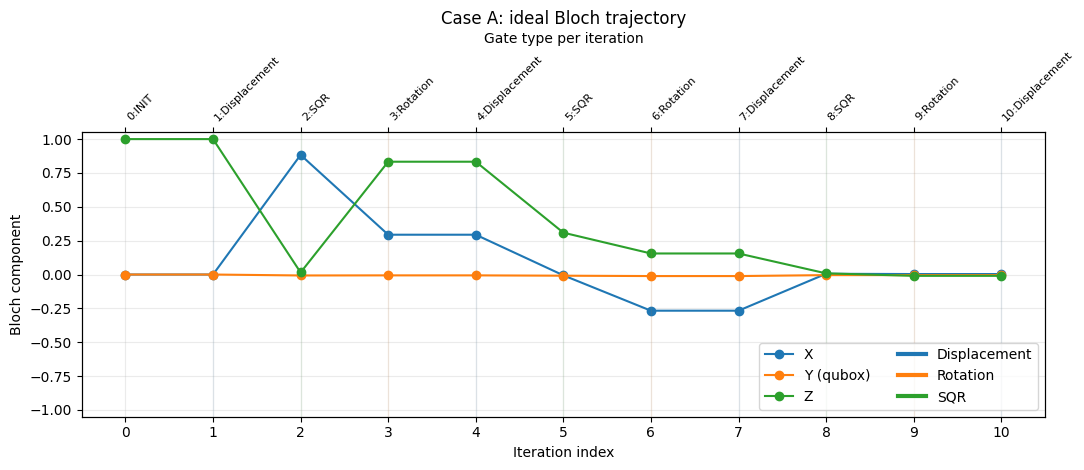

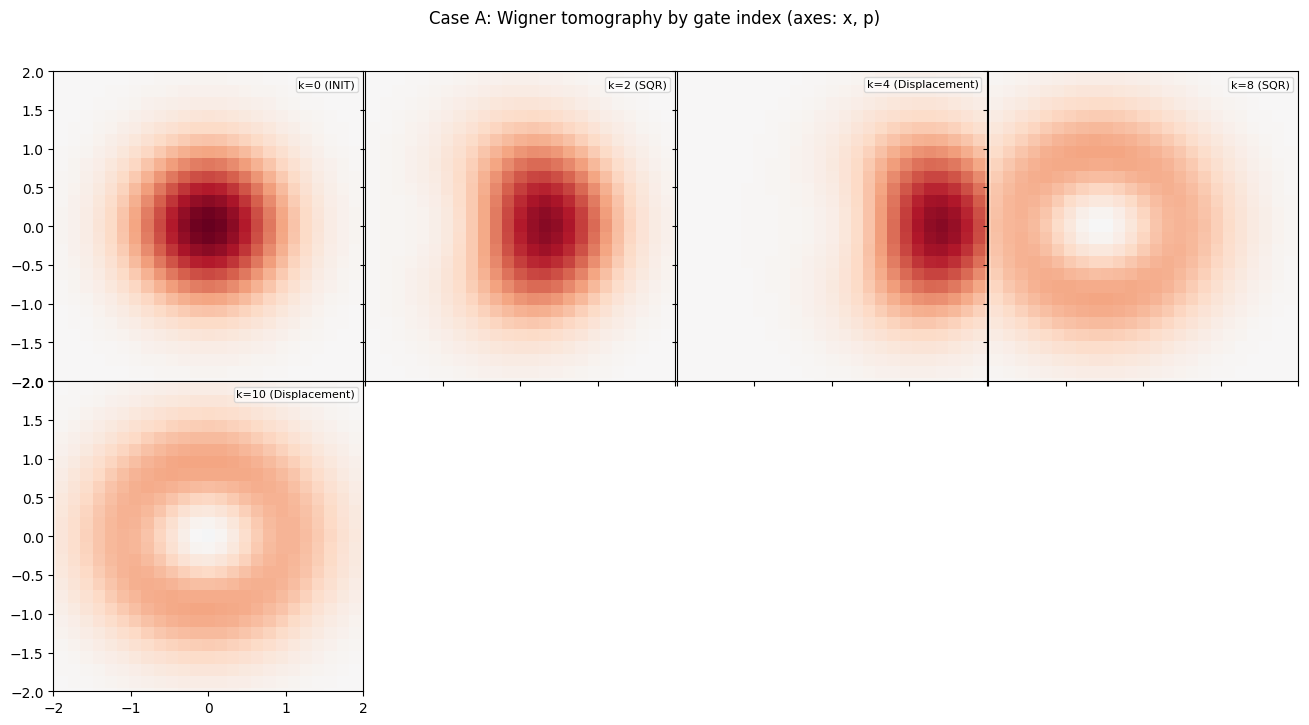

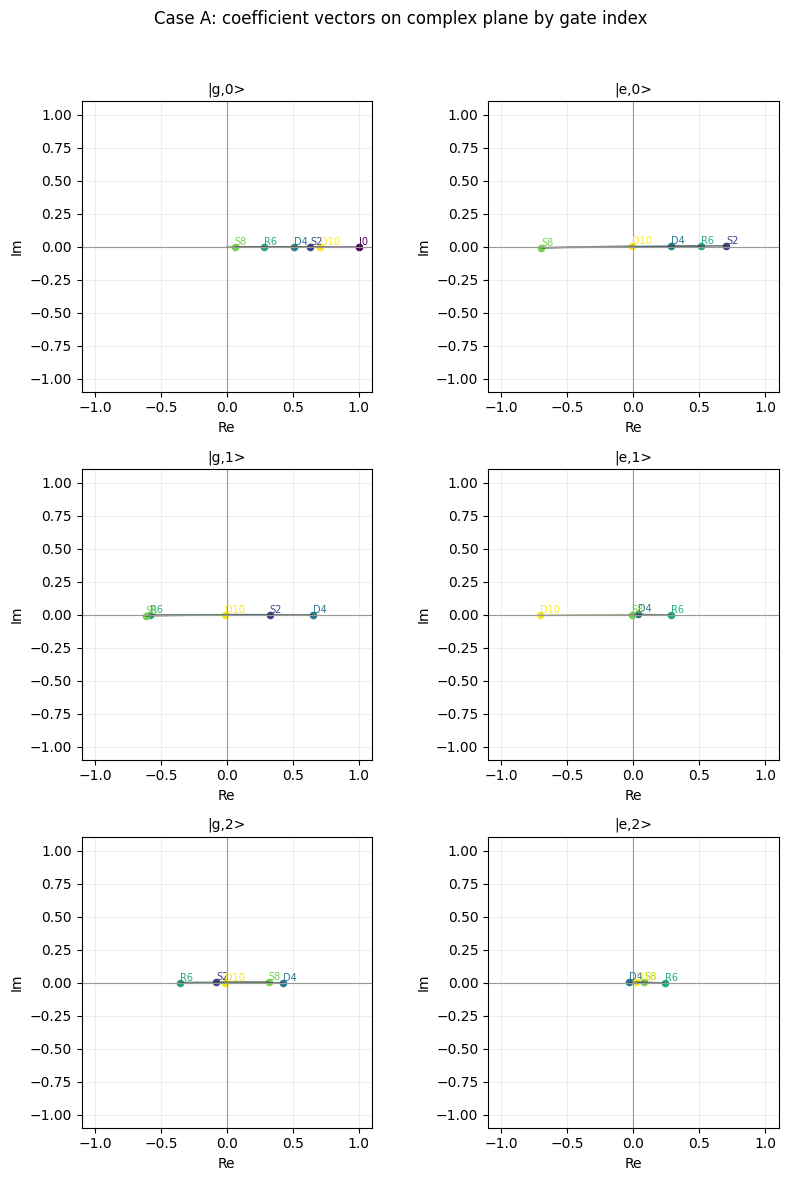

In [5]:
CASE_A = run_case_a(GATES, CONFIG, case_label="Case A")

print("Case A diagnostics:")
print(
    {
        "solver": CASE_A["metadata"]["solver"],
        "final_x": CASE_A["x"][-1],
        "final_y": CASE_A["y"][-1],
        "final_z": CASE_A["z"][-1],
        "final_n": CASE_A["n"][-1],
    }
)

plot_bloch_track(CASE_A, title="Case A: ideal Bloch trajectory", label_stride=int(CONFIG["top_axis_label_stride"]))
plt.show()

plot_wigner_grid(CASE_A, title="Case A: Wigner tomography by gate index", stride=int(CONFIG["wigner_stride"]), max_cols=int(CONFIG["wigner_max_cols"]))
plt.show()

fig = plot_complex_coeff_vector_grid(
    CASE_A,
    title="Case A: coefficient vectors on complex plane by gate index",
    max_n=int(CONFIG["phase_track_max_n"]),
    threshold=float(CONFIG["phase_reference_threshold"]),
    stride=int(CONFIG["wigner_stride"]),
    max_cols=int(CONFIG["wigner_max_cols"]),
)
plt.show()
plt.close(fig)


## Case A Holographic ZXZ Correlator

Apply `holographic_sim_cached` to the Case A combined gate unitary from this notebook and compute the ZXZ correlation profile across a 1D chain.

Attempting FORWARD-order Case A unitary with shape: (26, 26)
Requested holographic local dimension d = 26
Unitarity error (full): 4.618e-15
holographic_sim_cached currently supports qubits only (d=2).
Falling back to logical cavity-|0> 2x2 block extracted from the forward-order full unitary.
Fallback unitary shape: (2, 2)
Unitarity error (fallback): 1.353e-15
Run mode: fallback d=2 logical block
Sequential notebook Case A ZXZ center correlator mean (sampled) = -0.009000
Sequential notebook Case A ZXZ center correlator mean (exact from branch table) = 0.000645
Branch table probability sum = 1.000000000000
Representative cached branch table (center ZXZ placement):
    s9  s10  s11      prob    weight
0  1.0  1.0  1.0  0.262817  1.0+0.0j
1  1.0  1.0 -1.0  0.249797 -1.0+0.0j
2  1.0 -1.0  1.0  0.000044 -1.0+0.0j
3  1.0 -1.0 -1.0  0.000041  1.0+0.0j
4 -1.0  1.0  1.0  0.249797 -1.0+0.0j
Null-observable sanity mean (should be ~1): 1.000000


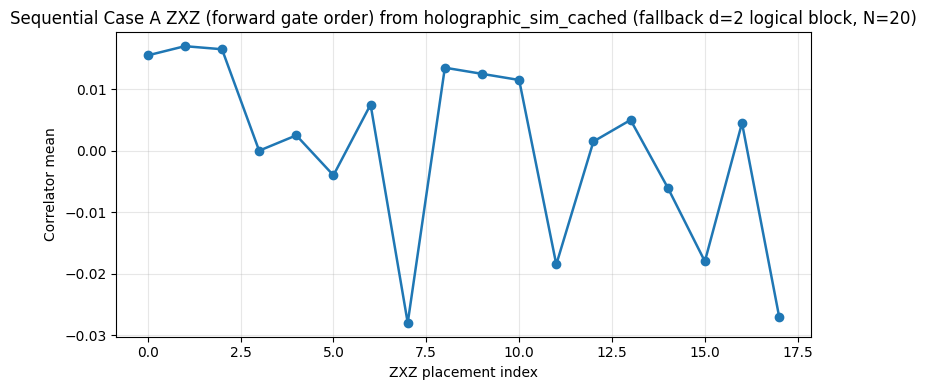

In [6]:
from pathlib import Path
import sys

from cqed_sim.simulators.ideal import ideal_gate_unitary

HOLOGRAPHIC_SIM_ROOT = Path(r"C:\Users\dazzl\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\JJL_Experiments\holographic_sim")
if HOLOGRAPHIC_SIM_ROOT.exists() and str(HOLOGRAPHIC_SIM_ROOT) not in sys.path:
    sys.path.insert(0, str(HOLOGRAPHIC_SIM_ROOT))

try:
    from holographicSim import holographic_sim_cached
except Exception as exc:
    raise ImportError(f"Could not import holographic_sim_cached from {HOLOGRAPHIC_SIM_ROOT}") from exc

HOLOGRAPHIC_N = 20
HOLOGRAPHIC_SHOTS = 4000
ALLOW_D2_FALLBACK = True


def _real_mean(samples) -> float:
    arr = np.asarray(samples, dtype=np.complex128)
    return float(np.real(np.mean(arr)))


def _nearest_unitary(mat: np.ndarray) -> np.ndarray:
    u, _, vh = np.linalg.svd(mat)
    return (u @ vh).astype(np.complex128)


def _logical_paulis_in_dim(d: int) -> tuple[np.ndarray, np.ndarray]:
    """Embed qubit X/Z on levels 0,1 inside a d-dimensional local Hilbert space."""
    x = np.zeros((d, d), dtype=np.complex128)
    z = np.eye(d, dtype=np.complex128)
    x[0, 1] = 1.0
    x[1, 0] = 1.0
    z[1, 1] = -1.0
    return x, z


def _exact_mean_from_df(df) -> float:
    probs = np.asarray(df["prob"], dtype=float)
    weights = np.asarray(df["weight"], dtype=np.complex128)
    return float(np.real(np.sum(probs * weights)))


def _forward_case_a_gates():
    if bool(CONFIG.get("reverse_gate_order", False)):
        _, forward_gates = load_gate_sequence(GATE_PATH)
        return list(forward_gates)
    return list(GATES)


def _combined_ideal_unitary(gates, n_cav_dim: int) -> np.ndarray:
    total = None
    for gate in gates:
        unitary = ideal_gate_unitary(gate, n_cav_dim)
        total = unitary if total is None else unitary * total
    if total is None:
        raise ValueError("Need at least one gate to build a combined unitary.")
    return np.asarray(total.full(), dtype=np.complex128)


def compute_zxz_curve_cached(U_total: np.ndarray, n_sites: int = HOLOGRAPHIC_N, shot_nums: int = HOLOGRAPHIC_SHOTS):
    d_local = int(U_total.shape[0])
    if U_total.shape != (d_local, d_local):
        raise ValueError(f"U_total must be square, got shape {U_total.shape}")

    pauli_x, pauli_z = _logical_paulis_in_dim(d_local)

    vals = []
    for i in range(n_sites - 2):
        op_list = [None] * n_sites
        op_list[i] = pauli_z
        op_list[i + 1] = pauli_x
        op_list[i + 2] = pauli_z
        samples = holographic_sim_cached([U_total] * n_sites, op_list, shot_nums=shot_nums, d=d_local)
        vals.append(_real_mean(samples))

    center = n_sites // 2 - 1
    center_ops = [None] * n_sites
    center_ops[center] = pauli_z
    center_ops[center + 1] = pauli_x
    center_ops[center + 2] = pauli_z
    center_samples, center_df = holographic_sim_cached(
        [U_total] * n_sites,
        center_ops,
        shot_nums=shot_nums,
        d=d_local,
        return_df=True,
    )
    center_mean = _real_mean(center_samples)
    center_mean_exact = _exact_mean_from_df(center_df)
    return np.asarray(vals, dtype=float), center_mean, center_mean_exact, center_df


forward_case_a_gates = _forward_case_a_gates()
U_case_a_full = _combined_ideal_unitary(forward_case_a_gates, int(CONFIG["n_cav_dim"]))
d_full = int(U_case_a_full.shape[0])
unitarity_err_full = np.linalg.norm(U_case_a_full.conj().T @ U_case_a_full - np.eye(d_full, dtype=np.complex128))
print(f"Attempting FORWARD-order Case A unitary with shape: {U_case_a_full.shape}")
print(f"Requested holographic local dimension d = {d_full}")
print(f"Unitarity error (full): {unitarity_err_full:.3e}")

U_case_a_eval = U_case_a_full
d_eval = d_full

try:
    zxz_curve_case_a_seq, zxz_center_mean_case_a_seq, zxz_center_mean_exact_case_a_seq, zxz_center_df_case_a_seq = compute_zxz_curve_cached(
        U_case_a_full,
        n_sites=HOLOGRAPHIC_N,
        shot_nums=HOLOGRAPHIC_SHOTS,
    )
    run_mode = f"full d={d_full}"
except ValueError as exc:
    if (not ALLOW_D2_FALLBACK) or ("d=2" not in str(exc) and "qubits only" not in str(exc)):
        raise

    print("holographic_sim_cached currently supports qubits only (d=2).")
    print("Falling back to logical cavity-|0> 2x2 block extracted from the forward-order full unitary.")

    U_case_a_holo = _nearest_unitary(U_case_a_full[:2, :2])
    unitarity_err_2 = np.linalg.norm(U_case_a_holo.conj().T @ U_case_a_holo - np.eye(2, dtype=np.complex128))
    print(f"Fallback unitary shape: {U_case_a_holo.shape}")
    print(f"Unitarity error (fallback): {unitarity_err_2:.3e}")

    U_case_a_eval = U_case_a_holo
    d_eval = 2
    zxz_curve_case_a_seq, zxz_center_mean_case_a_seq, zxz_center_mean_exact_case_a_seq, zxz_center_df_case_a_seq = compute_zxz_curve_cached(
        U_case_a_holo,
        n_sites=HOLOGRAPHIC_N,
        shot_nums=HOLOGRAPHIC_SHOTS,
    )
    run_mode = "fallback d=2 logical block"

print(f"Run mode: {run_mode}")
print(f"Sequential notebook Case A ZXZ center correlator mean (sampled) = {zxz_center_mean_case_a_seq:.6f}")
print(f"Sequential notebook Case A ZXZ center correlator mean (exact from branch table) = {zxz_center_mean_exact_case_a_seq:.6f}")
print(f"Branch table probability sum = {float(np.asarray(zxz_center_df_case_a_seq['prob'], dtype=float).sum()):.12f}")
print("Representative cached branch table (center ZXZ placement):")
print(zxz_center_df_case_a_seq.head())

# Basic implementation sanity check: with no observables, weight should be identically 1.
null_samples = holographic_sim_cached([U_case_a_eval] * 6, [None] * 6, shot_nums=2000, d=d_eval)
print(f"Null-observable sanity mean (should be ~1): {_real_mean(null_samples):.6f}")

plt.figure(figsize=(8.0, 4.0))
plt.plot(zxz_curve_case_a_seq, marker="o", linewidth=1.8)
plt.title(f"Sequential Case A ZXZ (forward gate order) from holographic_sim_cached ({run_mode}, N={HOLOGRAPHIC_N})")
plt.xlabel("ZXZ placement index")
plt.ylabel("Correlator mean")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Section 6: Case B --- Pulse-level Simulation (No Dissipation)

SQR note:

`cqed_sim` provides dispersive manifold-frequency helpers, but not a fully hardware-calibrated selective-SQR compiler. Case B therefore uses a simplified multitone Gaussian rotating-wave model:

- one Gaussian-windowed tone per active Fock manifold,
- tone frequencies from `cqed_sim.snap_opt.model.manifold_transition_frequency(...)`,
- per-tone area calibration `theta_n ~= integral Omega_n(t) dt`.


Case B diagnostics:
{'solver': 'sesolve', 'final_x': np.float64(-0.3016124547818512), 'final_y': np.float64(-0.1602753279220039), 'final_z': np.float64(-0.21303046995299546), 'final_n': np.float64(0.7857911755537172)}
Case B gate-to-pulse mapping:
k= 1 Displacement Square cavity drive with analytic rotating-frame calibration alpha = -i * integral epsilon(t) dt.
k= 2 SQR          Simplified multitone Gaussian SQR with canonical waveform convention w(t)~exp(+i*omega*t); tone amplitudes follow additive correction amp_n = theta/(2T) + lambda0*d_lambda_norm (equivalent to coefficient theta/pi + d_lambda_norm).
k= 3 Rotation     Gaussian qubit drive with analytic RWA calibration theta = 2 * integral Omega(t) dt.
k= 4 Displacement Square cavity drive with analytic rotating-frame calibration alpha = -i * integral epsilon(t) dt.
k= 5 SQR          Simplified multitone Gaussian SQR with canonical waveform convention w(t)~exp(+i*omega*t); tone amplitudes follow additive correction amp_n = theta/(2

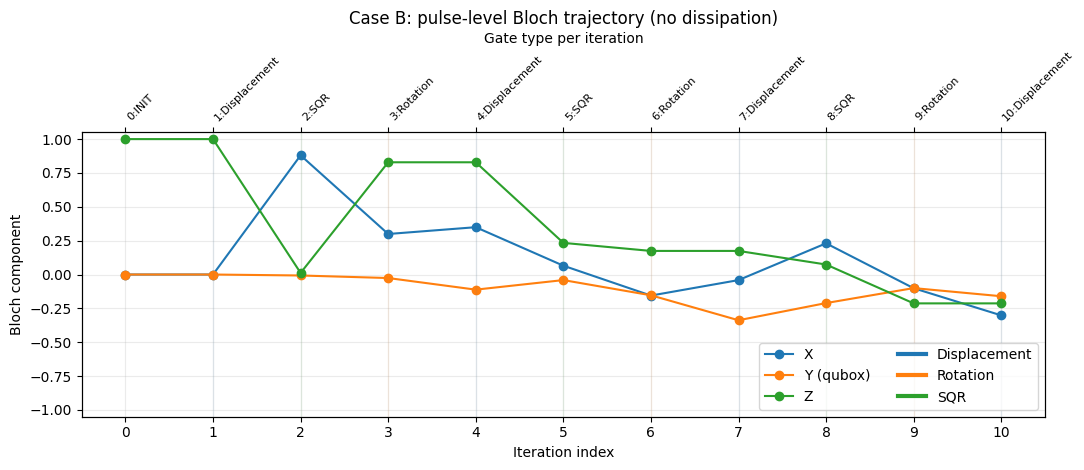

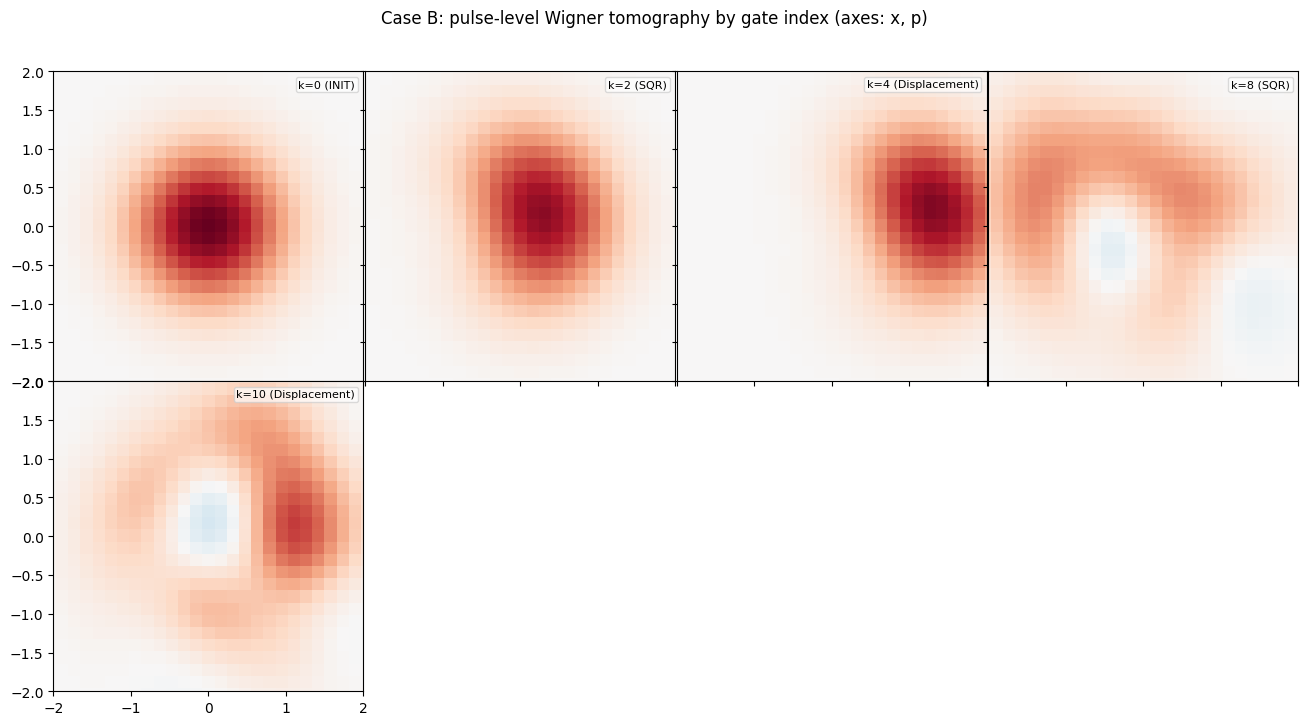

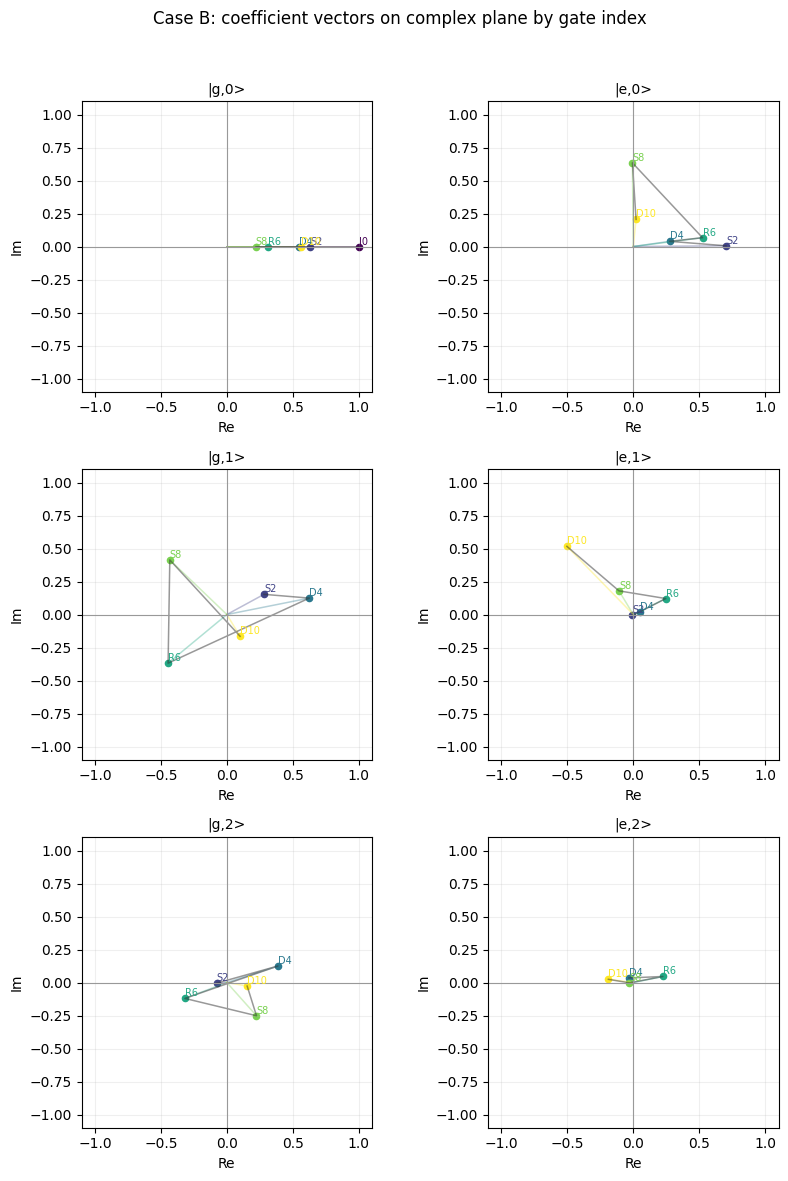

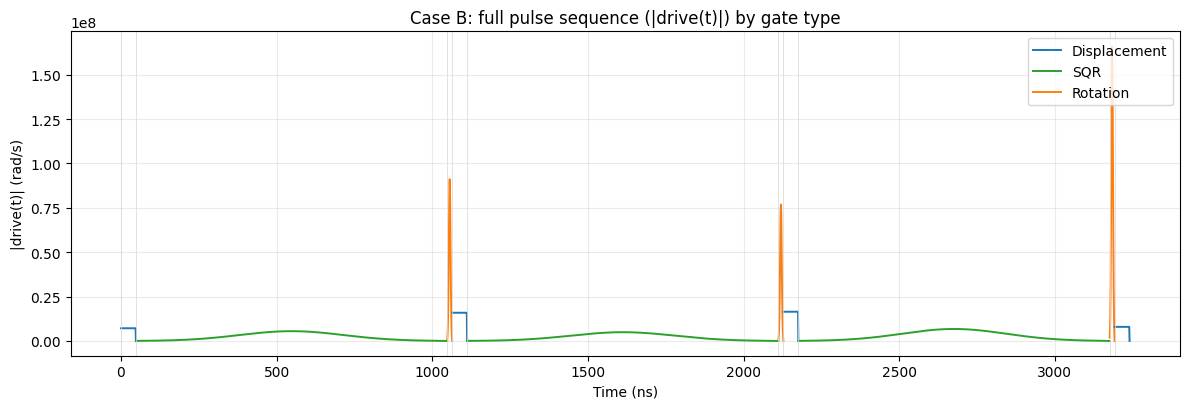

In [7]:
CASE_B = run_case_b(GATES, CONFIG, case_label="Case B")

print("Case B diagnostics:")
print(
    {
        "solver": CASE_B["metadata"]["solver"],
        "final_x": CASE_B["x"][-1],
        "final_y": CASE_B["y"][-1],
        "final_z": CASE_B["z"][-1],
        "final_n": CASE_B["n"][-1],
    }
)
print("Case B gate-to-pulse mapping:")
print_mapping_rows(CASE_B)

plot_bloch_track(CASE_B, title="Case B: pulse-level Bloch trajectory (no dissipation)", label_stride=int(CONFIG["top_axis_label_stride"]))
plt.show()

plot_wigner_grid(CASE_B, title="Case B: pulse-level Wigner tomography by gate index", stride=int(CONFIG["wigner_stride"]), max_cols=int(CONFIG["wigner_max_cols"]))
plt.show()

fig = plot_complex_coeff_vector_grid(
    CASE_B,
    title="Case B: coefficient vectors on complex plane by gate index",
    max_n=int(CONFIG["phase_track_max_n"]),
    threshold=float(CONFIG["phase_reference_threshold"]),
    stride=int(CONFIG["wigner_stride"]),
    max_cols=int(CONFIG["wigner_max_cols"]),
)
plt.show()
plt.close(fig)

fig = plot_full_pulse_sequence_by_gate_type(CASE_B, GATES, CONFIG)
plt.show()
plt.close(fig)



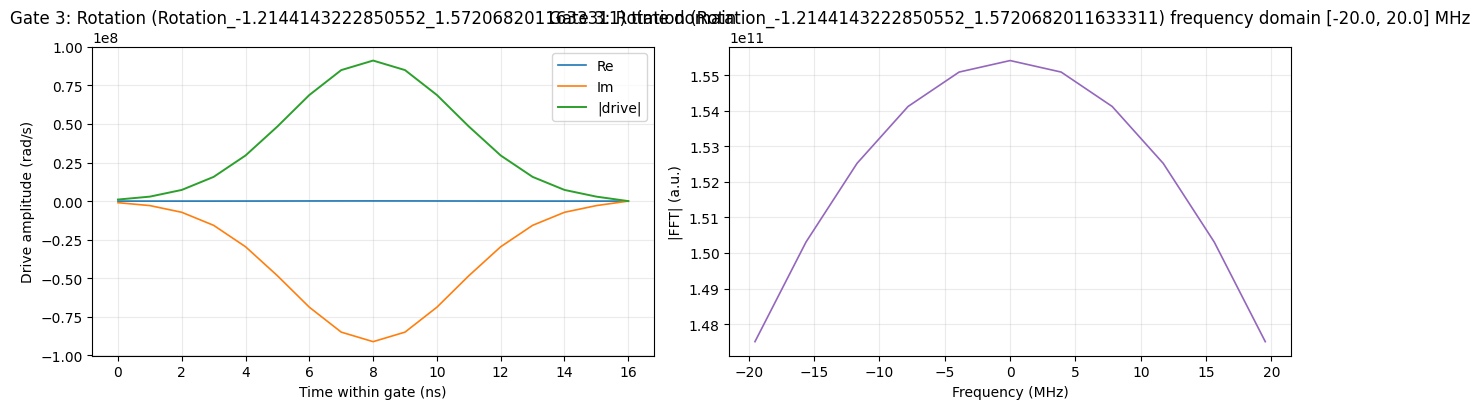

In [8]:
selected_gate_for_pulse_view = 3
fig = plot_gate_pulse_time_and_frequency(
    CASE_B,
    GATES,
    CONFIG,
    gate_index=selected_gate_for_pulse_view,
    freq_min_mhz=-20,
    freq_max_mhz=20,
)
plt.show()
plt.close(fig)

## Section 7: Case C --- Pulse-level Simulation (Sequential State-Target SQR Optimization)

This section replaces the old independent SQR calibration flow with **sequential state-target optimization**:

- for each SQR gate in order, prepare the pulse-level state up to that gate using previously optimized SQRs,
- use the corresponding **Case A ideal post-gate state** as the target (including relative phase structure),
- optimize only that SQR pulse to maximize target-state fidelity,
- carry the updated calibration forward to the next SQR.


Case C optimized SQR gates:
{'sequence_gate_index': 2, 'index': 8, 'name': 'SQR_789278ba62949511b06e9d76a4bb8437', 'mode': 'amp_phase_detuning_ramp', 'strategy': 'sequential_state_target', 'objective_scope': 'global', 'baseline_target_state_fid': 0.9770794551257771, 'optimized_target_state_fid': 0.9799528096891751, 'target_state_fid_gain': 0.0028733545633979896, 'baseline_target_state_weakness': 0.022920544874222903, 'optimized_target_state_weakness': 0.020047190310824914, 'baseline_mean_fid': 0.46008716223452206, 'optimized_mean_fid': 0.46021532057354037, 'baseline_min_fid': 0.006867728151050612, 'optimized_min_fid': 0.00679148723857369, 'baseline_phase_rms': 0.43346402074323864, 'optimized_phase_rms': 0.43346402074323864, 'objective_calls': 1262}
{'sequence_gate_index': 5, 'index': 5, 'name': 'SQR_bc8194a85a260be4c0959c6c4d8d7ae1', 'mode': 'amp_phase_detuning_ramp', 'strategy': 'sequential_state_target', 'objective_scope': 'global', 'baseline_target_state_fid': 0.9202662771593808, 'o

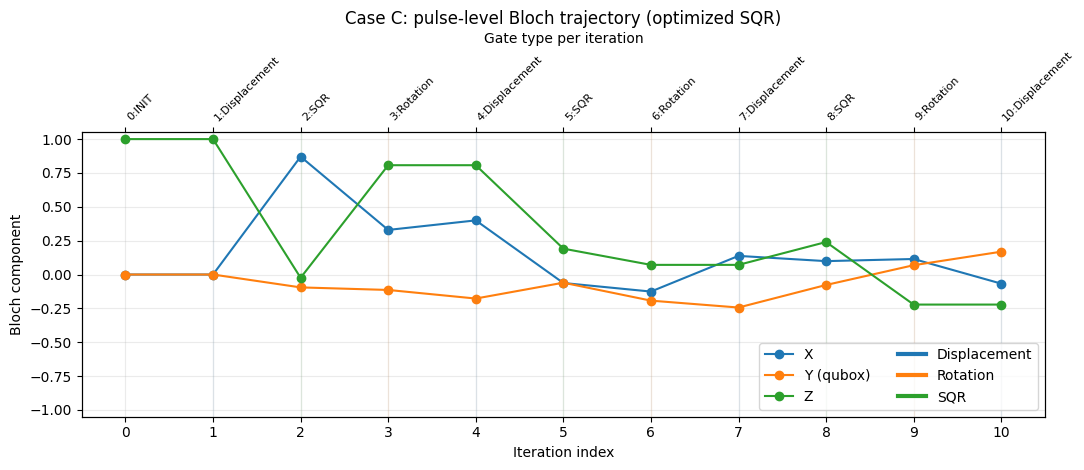

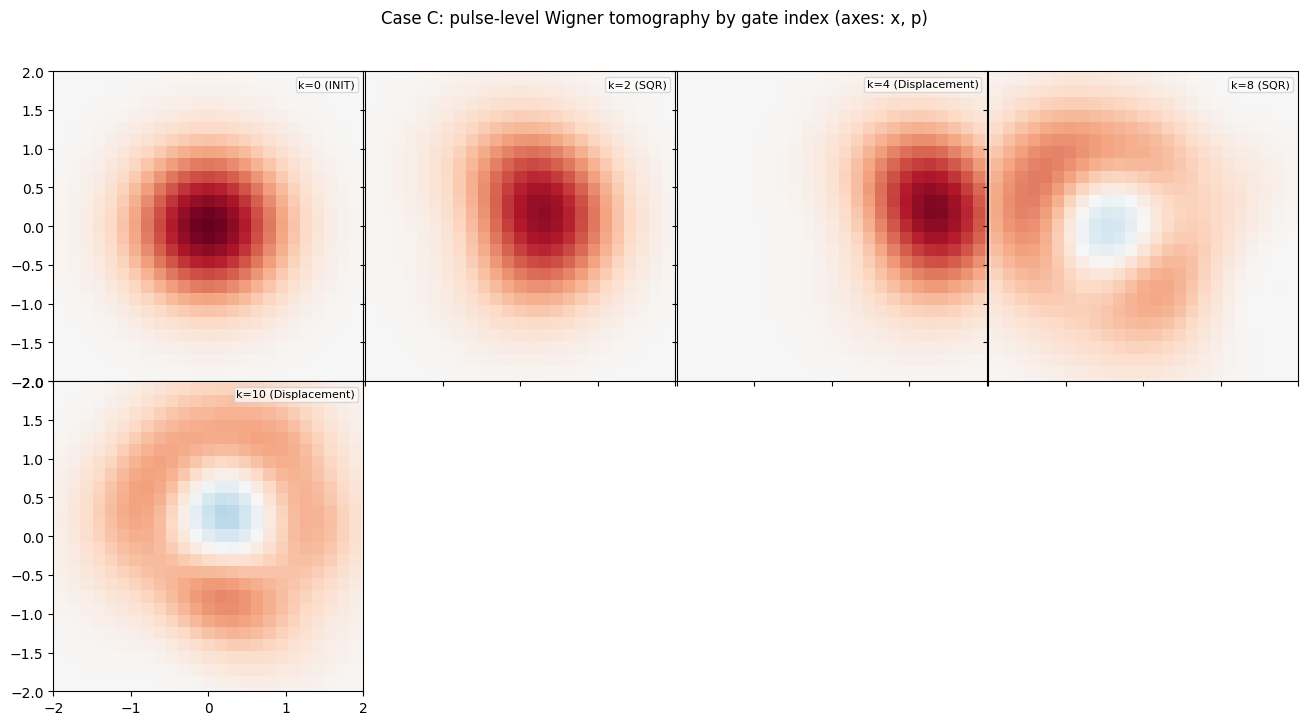

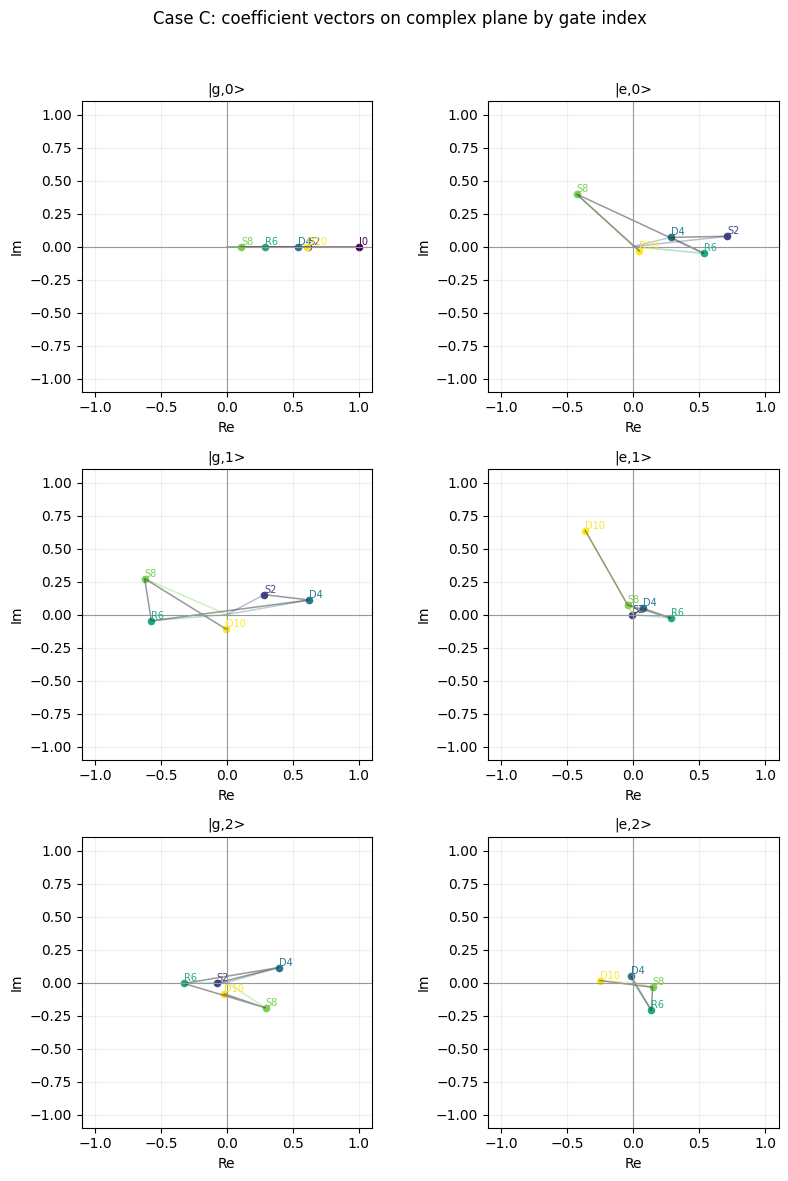

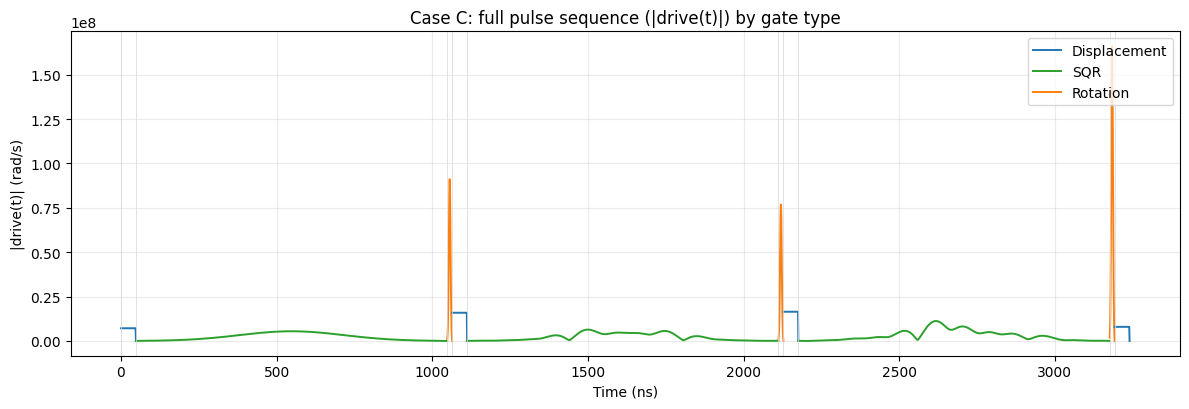

In [9]:
CASE_C_OPT = build_case_c_calibration_map(GATES, CONFIG, ideal_track=CASE_A)
CASE_C_CALIBRATION_MAP = CASE_C_OPT["calibration_map"]
CASE_C_OPT_SUMMARY = CASE_C_OPT["summary_rows"]

print("Case C optimized SQR gates:")
for row in CASE_C_OPT_SUMMARY:
    print(row)


if CASE_C_OPT_SUMMARY:
    baseline_vals = [float(row.get("baseline_target_state_fid", np.nan)) for row in CASE_C_OPT_SUMMARY]
    optimized_vals = [float(row.get("optimized_target_state_fid", np.nan)) for row in CASE_C_OPT_SUMMARY]
    print("Case C sequential state-target fidelity summary:")
    print({
        "mean_baseline_target_state_fid": float(np.nanmean(np.asarray(baseline_vals, dtype=float))),
        "mean_optimized_target_state_fid": float(np.nanmean(np.asarray(optimized_vals, dtype=float))),
        "mean_target_state_fid_gain": float(np.nanmean(np.asarray(optimized_vals, dtype=float) - np.asarray(baseline_vals, dtype=float))),
    })

CASE_C = run_pulse_case(
    GATES,
    CONFIG,
    include_dissipation=False,
    case_label="Case C",
    sqr_calibration_map=CASE_C_CALIBRATION_MAP,
)

print("Case C diagnostics:")
print(
    {
        "solver": CASE_C["metadata"]["solver"],
        "final_x": CASE_C["x"][-1],
        "final_y": CASE_C["y"][-1],
        "final_z": CASE_C["z"][-1],
        "final_n": CASE_C["n"][-1],
    }
)
print("Case C gate-to-pulse mapping:")
print_mapping_rows(CASE_C)

plot_bloch_track(CASE_C, title="Case C: pulse-level Bloch trajectory (optimized SQR)", label_stride=int(CONFIG["top_axis_label_stride"]))
plt.show()

plot_wigner_grid(CASE_C, title="Case C: pulse-level Wigner tomography by gate index", stride=int(CONFIG["wigner_stride"]), max_cols=int(CONFIG["wigner_max_cols"]))
plt.show()

fig = plot_complex_coeff_vector_grid(
    CASE_C,
    title="Case C: coefficient vectors on complex plane by gate index",
    max_n=int(CONFIG["phase_track_max_n"]),
    threshold=float(CONFIG["phase_reference_threshold"]),
    stride=int(CONFIG["wigner_stride"]),
    max_cols=int(CONFIG["wigner_max_cols"]),
)
plt.show()
plt.close(fig)

fig = plot_full_pulse_sequence_by_gate_type(CASE_C, GATES, CONFIG)
plt.show()
plt.close(fig)


## Section Y: Gate-Indexed Diagnostics and Pulse-Level Trajectories


{'overlay_cases': ['Case B', 'Case C'], 'n_max': 2, 'selected_gate_index': 2, 'selected_gate_type': 'SQR', 'selected_gate_name': 'SQR_789278ba62949511b06e9d76a4bb8437'}
Case A relative-phase debug at gate index 2:
  basis ordering: |q>_qubit tensor |n>_cavity = qt.tensor(qubit, cavity)
  reference: |g,0> targets: |g,n> and |e,n>
  c_g0 = (0.6293341562721951+0j)
  c_g0 = (0.6293341562721951+0j) | coherence=<g,0|rho|g,0>=(0.3960614802508357+0j) | phi_g=0.0 | plotted_phi_g=0.0
  c_e0 = (0.7017209297115499+0.005557446973075652j) | coherence=<e,0|rho|g,0>=(0.4416169492385586+0.00349749120182803j) | phi_e=0.007919573936363493 | plotted_phi_e=0.007919573936363495
  c_g1 = (0.324090137072456-0.0007297729449070609j) | coherence=<g,1|rho|g,0>=(0.20396099297063416-0.0004592710405533603j) | phi_g=-0.0022517553853524013 | plotted_phi_g=-0.0022517553853524013
  c_e1 = (nan+nanj) | coherence=<e,1|rho|g,0>=0j | phi_e=nan | plotted_phi_e=nan
  c_g2 = (-0.07879244582698758+0.00035484502737798807j) | coh

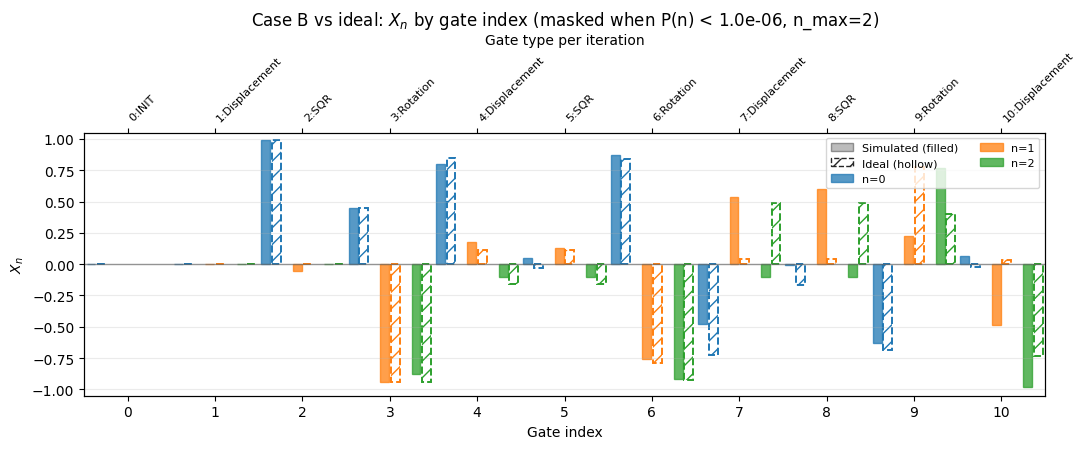

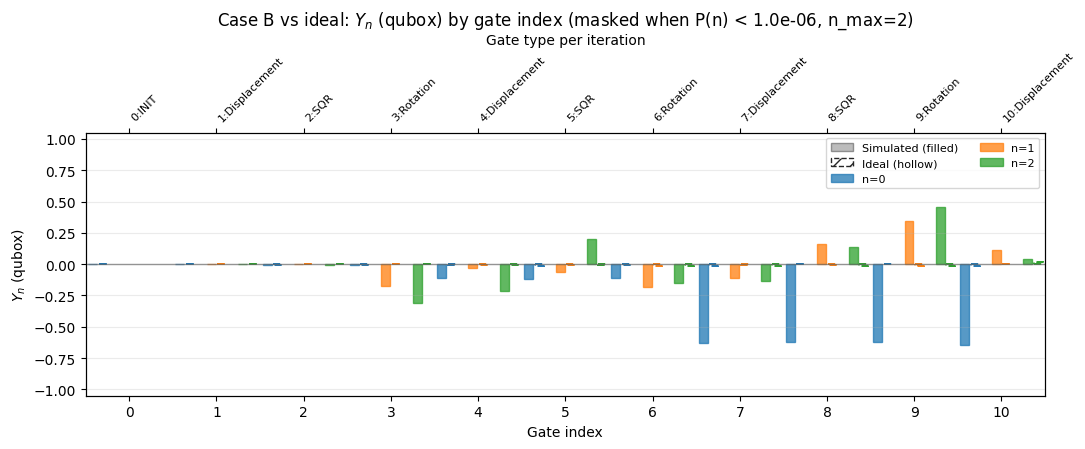

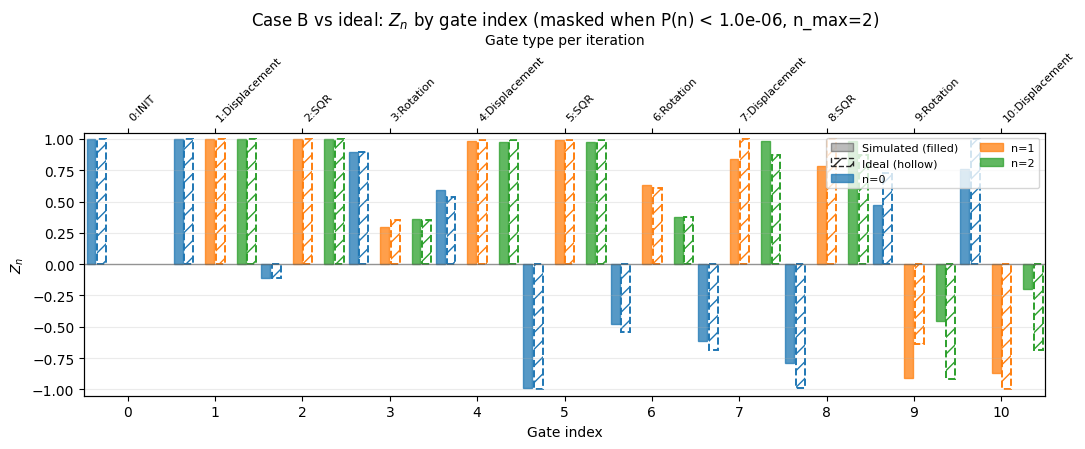

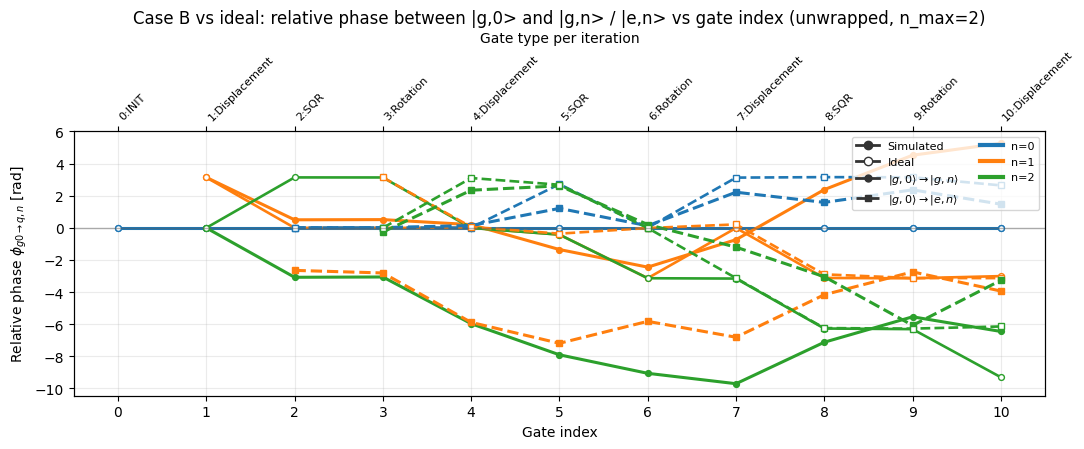

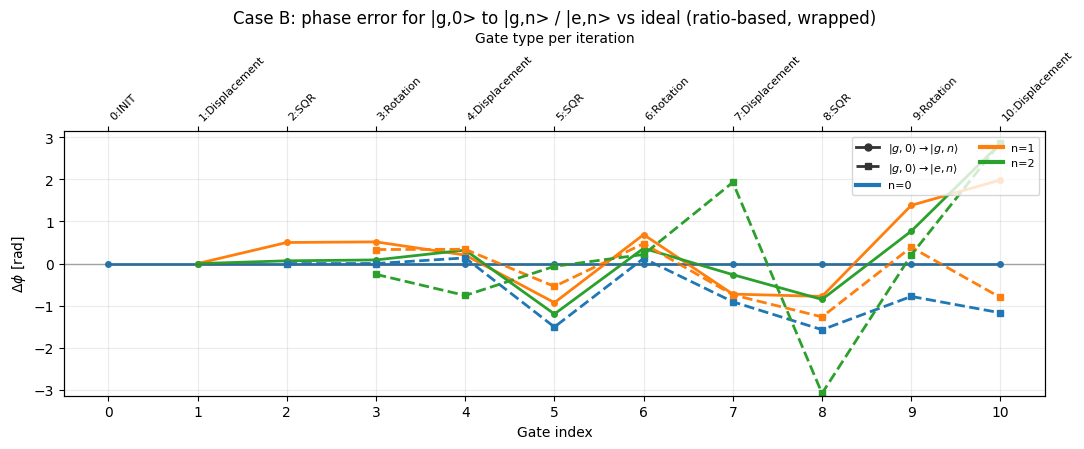

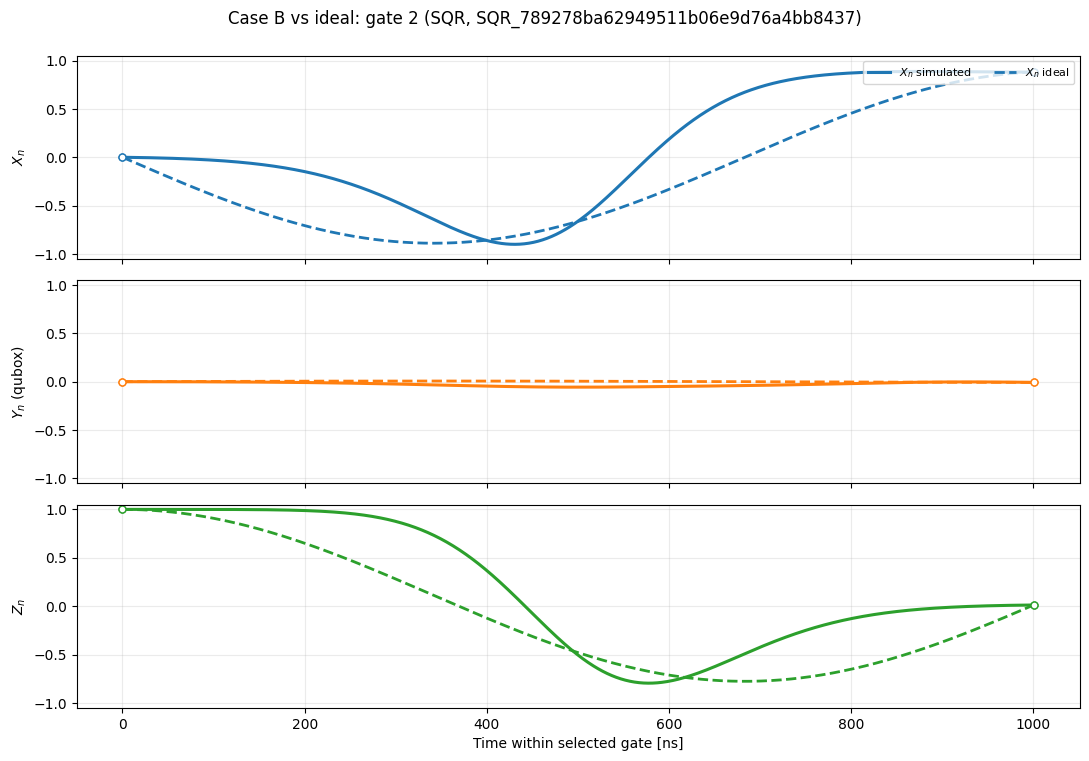

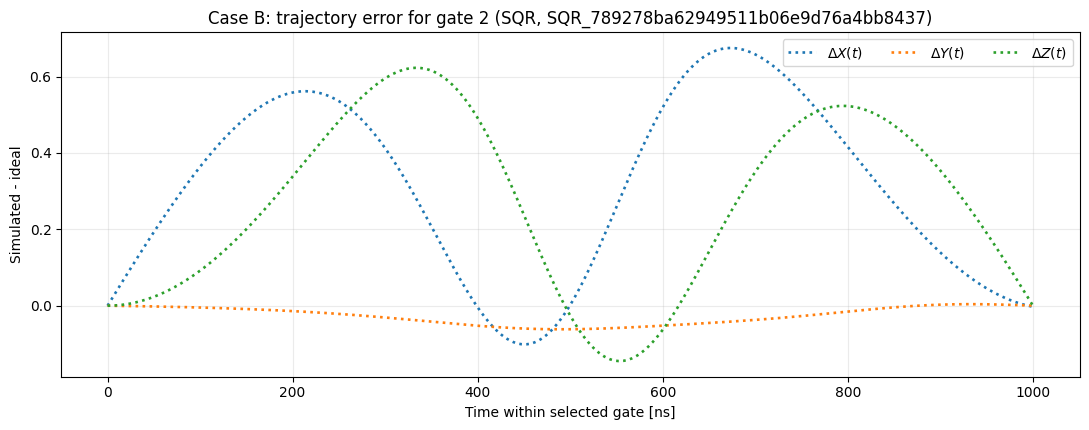

Overlay diagnostics for Case C:
Case C relative-phase debug at gate index 2:
  basis ordering: |q>_qubit tensor |n>_cavity = qt.tensor(qubit, cavity)
  reference: |g,0> targets: |g,n> and |e,n>
  c_g0 = (0.6158570005469752+0j)
  c_g0 = (0.6158570005469752+0j) | coherence=<g,0|rho|g,0>=(0.37927984512271706+0j) | phi_g=0.0 | plotted_phi_g=0.0
  c_e0 = (0.7112714387751446+0.07761878780001408j) | coherence=<e,0|rho|g,0>=(0.4380414948587921+0.047802073840608826j) | phi_e=0.1086967008367464 | plotted_phi_e=0.10869670083674642
  c_g1 = (0.2826373297753479+0.1506113251321405j) | coherence=<g,1|rho|g,0>=(0.17406417815805206+0.09275503894428531j) | phi_g=0.48960306440065526 | plotted_phi_g=0.48960306440065526
  c_e1 = (-0.007257027535093563-0.004859257974173326j) | coherence=<e,1|rho|g,0>=(-0.004469291210649531-0.0029926080408583557j) | phi_e=-2.5515665639295406 | plotted_phi_e=-2.5515665639295406
  c_g2 = (-0.07676209665590654-0.00429207269771337j) | coherence=<g,2|rho|g,0>=(-0.0472744746022036

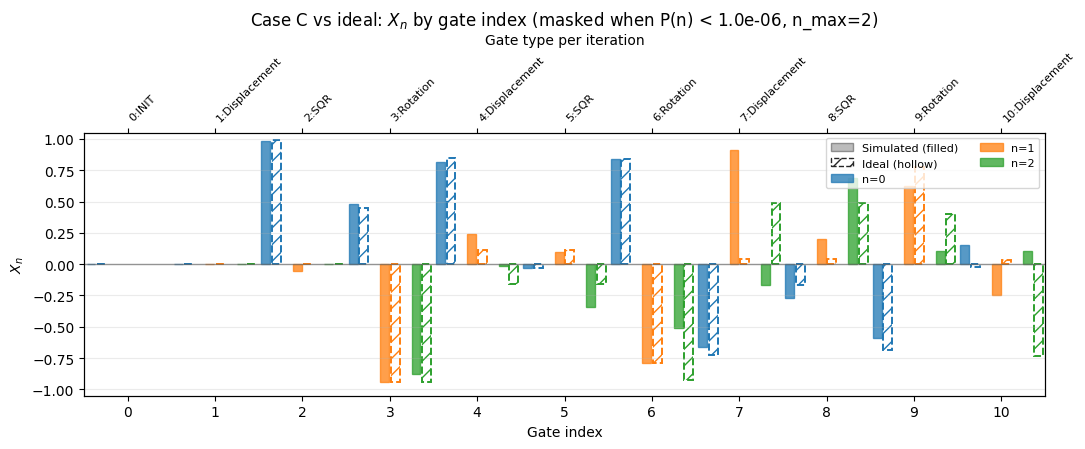

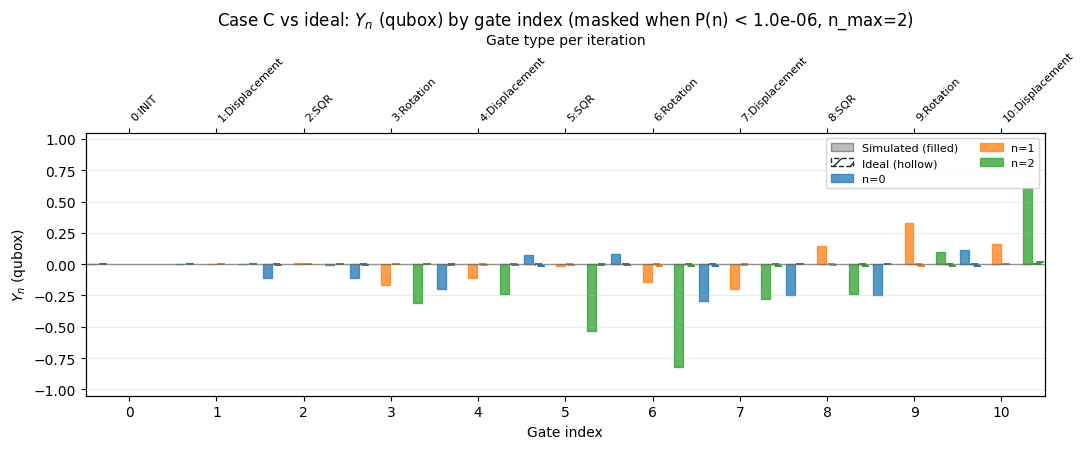

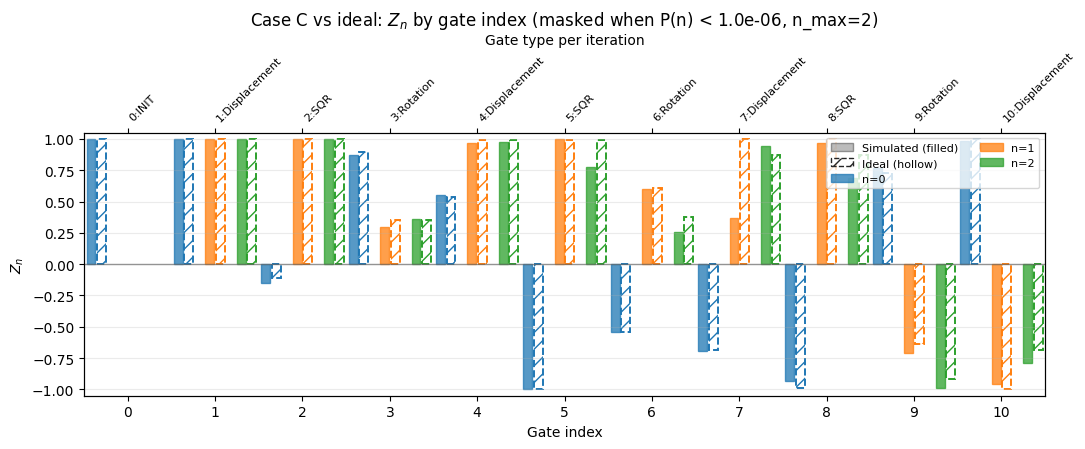

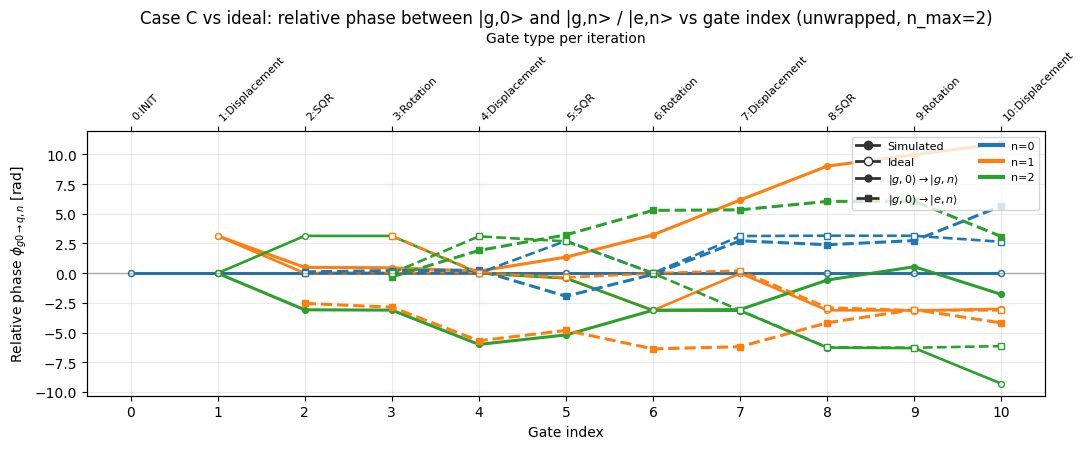

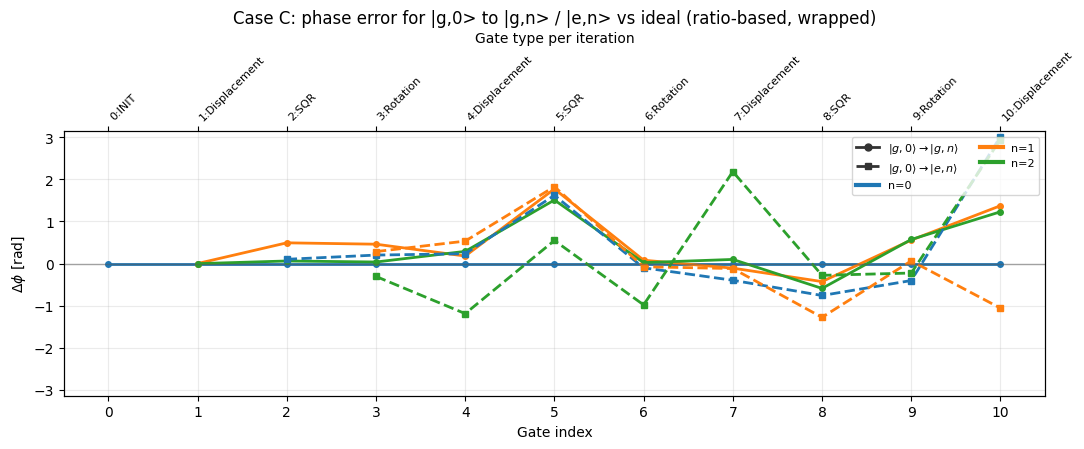

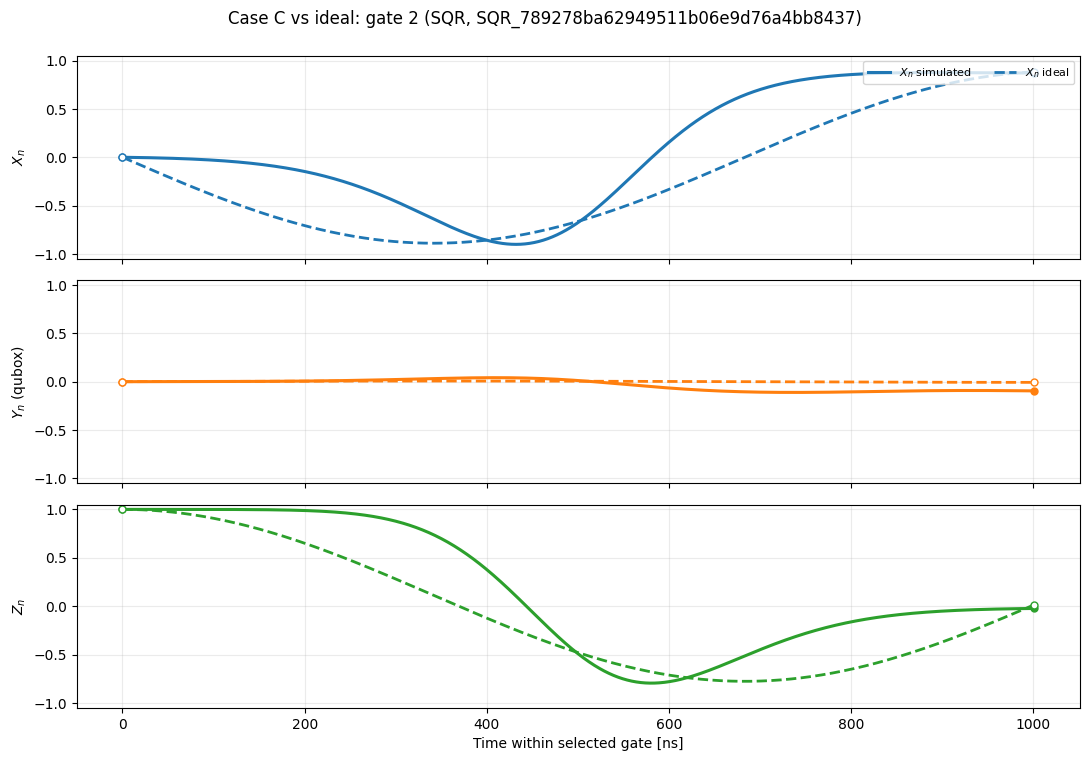

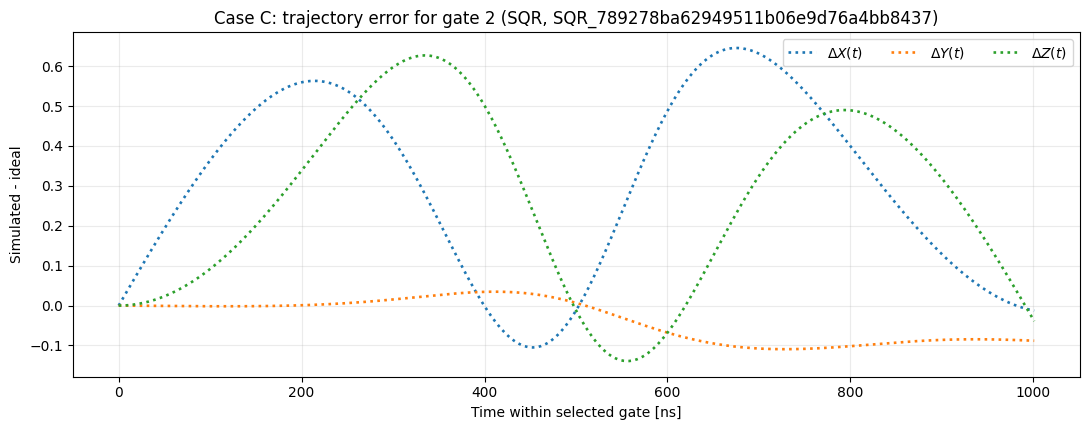

In [10]:
TRACKS = {
    "Case A": CASE_A,
    "Case B": CASE_B,
}
if "CASE_C" in globals():
    TRACKS["Case C"] = CASE_C
overlay_case_names = [str(name) for name in CONFIG["overlay_cases"]]
allowed_overlay = set(TRACKS.keys()) - {"Case A"}
for name in overlay_case_names:
    if name not in allowed_overlay:
        raise KeyError(f"Unsupported overlay case '{name}'. Expected one of {sorted(allowed_overlay)}.")

diagnostic_max_n = int(CONFIG["phase_track_max_n"])
probability_threshold = float(CONFIG["gate_diag_probability_threshold"])
label_stride = int(CONFIG["top_axis_label_stride"])
output_dir = Path(CONFIG["output_figure_dir"])
ideal_bloch = fock_resolved_bloch_diagnostics(CASE_A, max_n=diagnostic_max_n, probability_threshold=probability_threshold)
ideal_phase = relative_phase_family_diagnostics(
    CASE_A,
    max_n=diagnostic_max_n,
    probability_threshold=probability_threshold,
    unwrap=bool(CONFIG["phase_unwrap"]),
    coherence_threshold=probability_threshold,
)

if CONFIG["trajectory_gate_index"] is None:
    selected_gate_index = next((idx for idx, gate in enumerate(GATES, start=1) if gate.type == "SQR"), 1)
else:
    selected_gate_index = int(CONFIG["trajectory_gate_index"])

conditioned_cap = min(int(CONFIG["trajectory_conditioned_max_n"]), diagnostic_max_n)
conditioned_levels = list(range(conditioned_cap + 1))

print(
    {
        "overlay_cases": overlay_case_names,
        "n_max": diagnostic_max_n,
        "selected_gate_index": selected_gate_index,
        "selected_gate_type": GATES[selected_gate_index - 1].type,
        "selected_gate_name": GATES[selected_gate_index - 1].name,
    }
)

def _print_phase_debug(case_name, diagnostics, track):
    debug_snapshot = track["snapshots"][selected_gate_index]
    debug = relative_phase_debug_values(
        debug_snapshot["state"],
        max_n=diagnostic_max_n,
        probability_threshold=probability_threshold,
        coherence_threshold=probability_threshold,
    )
    print(f"{case_name} relative-phase debug at gate index {selected_gate_index}:")
    print("  basis ordering:", debug["basis_ordering"])
    print(
        "  reference:",
        debug["reference_label"],
        "targets:",
        debug["ground_target_template"],
        "and",
        debug["excited_target_template"],
    )
    print("  c_g0 =", debug["c_g0_gauge"])
    for row_idx, row in enumerate(debug["levels"]):
        plotted_ground = diagnostics["families"]["ground"]["phase"][row_idx, selected_gate_index]
        plotted_excited = diagnostics["families"]["excited"]["phase"][row_idx, selected_gate_index]
        print(
            f"  c_g{row['n']} = {row['c_gn_gauge']} | "
            f"coherence=<g,{row['n']}|rho|g,0>={row['coherence_gn_g0']} | "
            f"phi_g={row['ground_phase_rad']} | plotted_phi_g={plotted_ground}"
        )
        print(
            f"  c_e{row['n']} = {row['c_en_gauge']} | "
            f"coherence=<e,{row['n']}|rho|g,0>={row['coherence_en_g0']} | "
            f"phi_e={row['excited_phase_rad']} | plotted_phi_e={plotted_excited}"
        )
        if np.isfinite(row["ground_phase_rad"]) != np.isfinite(plotted_ground):
            raise AssertionError(f"{case_name} ground-family phase masking mismatch at n={row['n']}.")
        if np.isfinite(row["ground_phase_rad"]) and np.isfinite(plotted_ground):
            wrapped = (float(plotted_ground) - float(row["ground_phase_rad"]) + np.pi) % (2.0 * np.pi) - np.pi
            if abs(wrapped) > 1.0e-10:
                raise AssertionError(f"{case_name} plotted phase does not match extracted |g,0> -> |g,{row['n']}| phase.")
        if np.isfinite(row["excited_phase_rad"]) != np.isfinite(plotted_excited):
            raise AssertionError(f"{case_name} excited-family phase masking mismatch at n={row['n']}.")
        if np.isfinite(row["excited_phase_rad"]) and np.isfinite(plotted_excited):
            wrapped = (float(plotted_excited) - float(row["excited_phase_rad"]) + np.pi) % (2.0 * np.pi) - np.pi
            if abs(wrapped) > 1.0e-10:
                raise AssertionError(f"{case_name} plotted phase does not match extracted |g,0> -> |e,{row['n']}| phase.")

_print_phase_debug("Case A", ideal_phase, CASE_A)

OVERLAY_RESULTS = {}
for case_name in overlay_case_names:
    track = TRACKS[case_name]
    case_slug = case_name.lower().replace(" ", "_")
    sim_bloch = fock_resolved_bloch_diagnostics(track, max_n=diagnostic_max_n, probability_threshold=probability_threshold)
    sim_phase = relative_phase_family_diagnostics(
        track,
        max_n=diagnostic_max_n,
        probability_threshold=probability_threshold,
        unwrap=bool(CONFIG["phase_unwrap"]),
        coherence_threshold=probability_threshold,
    )
    sim_traj = simulate_gate_bloch_trajectory(
        track,
        GATES,
        CONFIG,
        gate_index=selected_gate_index,
        conditioned_n_levels=conditioned_levels,
        probability_threshold=probability_threshold,
    )
    ideal_traj = ideal_gate_bloch_trajectory(
        CASE_A,
        GATES,
        CONFIG,
        gate_index=selected_gate_index,
        times_s=sim_traj["times_s"],
        conditioned_n_levels=conditioned_levels,
        probability_threshold=probability_threshold,
    )
    OVERLAY_RESULTS[case_name] = {
        "bloch": sim_bloch,
        "phase": sim_phase,
        "trajectory": sim_traj,
        "ideal_trajectory": ideal_traj,
    }

    print(f"Overlay diagnostics for {case_name}:")
    _print_phase_debug(case_name, sim_phase, track)
    for component in ("x", "y", "z"):
        fig = plot_fock_resolved_bloch_grouped_bars(sim_bloch, ideal_bloch, track, component=component, label_stride=label_stride)
        if bool(CONFIG["save_output_figures"]):
            target = f"{case_slug}_bloch_{component.upper()}_grouped_bars.png"
            print("Saved:", save_figure(fig, output_dir, target, dpi=int(CONFIG["output_figure_dpi"])))
        plt.show()
        plt.close(fig)

    fig = plot_phase_overlay_lines(sim_phase, ideal_phase, track, label_stride=label_stride)
    if bool(CONFIG["save_output_figures"]):
        print("Saved:", save_figure(fig, output_dir, f"{case_slug}_relative_phase_vs_gate_index.png", dpi=int(CONFIG["output_figure_dpi"])))
    plt.show()
    plt.close(fig)

    fig = plot_phase_error_track(sim_phase, ideal_phase, track, label_stride=label_stride)
    if bool(CONFIG["save_output_figures"]):
        print("Saved:", save_figure(fig, output_dir, f"{case_slug}_phase_error_vs_gate_index.png", dpi=int(CONFIG["output_figure_dpi"])))
    plt.show()
    plt.close(fig)

    fig = plot_gate_bloch_trajectory_overlay(sim_traj, ideal_traj)
    if bool(CONFIG["save_output_figures"]):
        target = f"{case_slug}_bloch_trajectory_gate_{selected_gate_index}_sim_ideal.png"
        print("Saved:", save_figure(fig, output_dir, target, dpi=int(CONFIG["output_figure_dpi"])))
    plt.show()
    plt.close(fig)

    fig = plot_gate_bloch_trajectory_error(sim_traj, ideal_traj)
    if bool(CONFIG["save_output_figures"]):
        target = f"{case_slug}_bloch_trajectory_error_gate_{selected_gate_index}.png"
        print("Saved:", save_figure(fig, output_dir, target, dpi=int(CONFIG["output_figure_dpi"])))
    plt.show()
    plt.close(fig)



## Section 8: Weakness Metrics and Comparison Plots

Definitions used here:

- **Wigner negativity**: `0.5 * (integral |W| dx dp - 1)`.
- **Fidelity-based weakness**: `1 - F(rho_case, rho_A)` referenced to Case A at the same gate index.


In [11]:
CASE_A = attach_weakness_metrics(CASE_A, CASE_A)
CASE_B = attach_weakness_metrics(CASE_A, CASE_B)
if "CASE_C" in globals():
    CASE_C = attach_weakness_metrics(CASE_A, CASE_C)

print("Case B weakness snapshots (vs Case A):")
print(
    {
        "final_wigner_negativity": CASE_B["wigner_negativity"][-1],
        "final_fidelity_weakness_vs_a": CASE_B["fidelity_weakness_vs_a"][-1],
    }
)
if "CASE_C" in globals():
    print("Case C weakness snapshots (vs Case A):")
    print(
        {
            "final_wigner_negativity": CASE_C["wigner_negativity"][-1],
            "final_fidelity_weakness_vs_a": CASE_C["fidelity_weakness_vs_a"][-1],
        }
    )

COMPARISON_AB = comparison_metrics(CASE_A, CASE_B)
print("A vs B:", COMPARISON_AB)
if "CASE_C" in globals():
    COMPARISON_AC = comparison_metrics(CASE_A, CASE_C)
    COMPARISON_BC = comparison_metrics(CASE_B, CASE_C)
    print("A vs C:", COMPARISON_AC)
    print("B vs C:", COMPARISON_BC)


Case B weakness snapshots (vs Case A):
{'final_wigner_negativity': np.float64(0.017777883483537815), 'final_fidelity_weakness_vs_a': np.float64(0.1720182619987516)}
Case C weakness snapshots (vs Case A):
{'final_wigner_negativity': np.float64(0.031554130242993805), 'final_fidelity_weakness_vs_a': np.float64(0.18961293155667547)}
A vs B: {'x_rmse': 0.14343200587142532, 'y_rmse': 0.1398658787449985, 'z_rmse': 0.0921855859381239, 'n_rmse': 0.09739742495744162, 'final_fidelity': 0.8279817380012484}
A vs C: {'x_rmse': 0.14318733732206257, 'y_rmse': 0.12748743300464782, 'z_rmse': 0.12598928000292853, 'n_rmse': 0.12115330316847216, 'final_fidelity': 0.8103870684433245}
B vs C: {'x_rmse': 0.12484308700469114, 'y_rmse': 0.12974003628842337, 'z_rmse': 0.06940295366318243, 'n_rmse': 0.06134150794653345, 'final_fidelity': 0.9330409835518424}


e:\Programs\Lib\site-packages\qutip\core\data\expm.py:136: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))
